# Classification and Cross-Platform Validation Using DNA Methylation Data

### Academic Integrity Declaration

- Student Number: **40466218** 
- Name: **Conor Brown**
- Module: **ECS8055**
- Date: **1/2/2026**

By submitting this work, I declare that:
1. I have read and understood the University regulations relating to academic offences, including
collusion and plagiarism:
http://www.qub.ac.uk/directorates/AcademicStudentAffairs/AcademicAffairs/GeneralRegulations/
Procedures/ProceduresforDealingwithAcademicOffences/
2. The submission is my own original work and no part of it has been submitted for any other
assignment, except as otherwise permitted.
3. All sources used, including Generated-AI tools, published or unpublished, have been fully
acknowledged.
4. I give my consent for the work to be scanned using plagiarism detection software.

## Introduction

Medulloblastoma is the most common malignant brain tumour in children. A landmark paper in 2012 established four distinct molecular subgroups of medulloblastoma which they termed WNT, SHH, Group 3 and Group 4<sup>1</sup>. In 2019, Sharma et. al identified eight robust subtypes within Groups 3 and 4.<sup>2</sup> This classification was built purely using the HM450 array, but within the original dataset there were 110 EPIC samples that could be preprocessed on the EPIC array too. 

Our goal is to build a classification model that can accurately predict the subtypes using either the HM450 or the EPIC array, extending the functionality of the original classification. 

This first phase is focused on data collection and preparation. This involves several steps:

- Collecting the source data from the Gene Expression Omnibus
- Generating and cleaning EPIC beta values from raw .idat files using a DNA methylation preprocessing pipeline
- Identifying the intersection of HM450 and EPIC probes and selecting a subset of the most distinctive probes
- Identifying missing values and imputing them (in a way that respects the underlying biological structure)
- Performing dimensionality reduction to visually inspect whether our features can separate different subtypes
- Saving a factorised version of the dataset that represents the metagenes

This takes us from an original dataset of 866,519 features to a final dataset of 16 metagenes, and an original data size of 12GB down to just 0.3MB. 

Throughout this process what we are doing is attempting to separate the signal from the noise: removing technical errors and biological confounders from the raw DNA methylation data, removing probes that target housekeeping genes, removing samples and probes with non-random patterns of missingness and grouping together genes that share similar chacteristics.

This process is also necessary for computational efficiency: to build the classification model through multiple loops of cross-validation testing different hyperparameters, we need a manageable dataset to work with or we risk overburdening our computer's memory capacity. A persistent challenge in bioinformatics is handling those resource requirements with a reliable data processing pipeline.

The notebook is divided up into the following sections:

- Project Setup
- Loading Metadata
- DNA Methylation Preprocessing
- Data Loading
- Data Preparation
    - Filtering Data
    - Feature Selection
    - Handling Missing Values
    - Imputing Missing Values
- Dimensionality Reduction
    - Principal Components Analysis (PCA)
    - Uniform Manifold Approximation and Projection (UMAP)
    - Non-Negative Matrix Factorisation (NMF)

Each section header describes the key steps taken, the justification for important decisions, and the interpretation of important outcomes. Each code cell contains brief descriptions on what is being implemented.

## Project Setup


In [1]:
# Import libraries

from pathlib import Path
import warnings
import gc
import glob
import os

import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import plotly.express as px
from matplotlib.lines import Line2D
from umap import UMAP
import missingno as msno

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

import GEOparse
from pylluminator.annotations import Annotations, ArrayType, GenomeVersion
from pylluminator.samples import Samples, read_samples
from pylluminator.visualizations import betas_density, betas_dendrogram
from pylluminator.utils import set_logger, download_from_geo
from pylluminator.quality_control import *

# Define constants for all file paths
data_dir = Path("./data")
metadata_path = data_dir / "gse130051_metadata.parquet"

# EPIC (850k) Paths
epic_dir = data_dir / "epic"
epic_samples_load_path = epic_dir / "epic_raw_samples"
epic_betas_path = epic_dir / "epic_betas.parquet"
epic_top_probes_path = epic_dir / "epic_top_probes.parquet"
knn_imputed_epic_path = epic_dir / "knn_imputed_epic.parquet"
mice_imputed_epic_path = epic_dir / "mice_imputed_epic.parquet"

# HM450 (450k) Paths
hm450_dir = data_dir / "hm450"
hm450_betas_path = hm450_dir / "GSE130051_beta_values.csv"
hm450_betas_pq_dir = hm450_dir / "parquet"
hm450_top_probes_path = hm450_dir / "hm450_top_probes.parquet"

# Final Output Path
nmf_path = data_dir / "40466218_Conor_Brown_ECS8055_ICW_010226.csv"

random_state=40466218 # student id

# Global settings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (10, 6)

## Loading Metadata

First we download the metadata from the Gene Expression Omnibus using `GEOparse`. This allows us to:

- Identify the Medulloblastoma subtype for each sample
- Capture the two key sample identifiers used downstream (title e.g. `6026818126_R01C01` and geo_accession (aka GSM ID) e.g. `GSM3876338`) 
- Collect other background information like the sample cohort to check for batch effects

Over 100 samples are identified as `MBNOS` i.e. no tumour subtype could be identified in the original study<sup>2</sup>. They are excluded from downstream analysis. 

A clear class imbalance was identified with nearly 43% of all samples falling into group 7 and 8, while group 1 is just 3%. This will inform our train/test sampling approach in model development. This class imbalance is very similar in both HM450 and EPIC samples, but the group 1 shortage is less severe in the smaller EPIC sample.

In [2]:
# Download metadata from GEO

gse_id = "GSE130051"
dest_dir = "./data"
dest_path = Path(data_dir)

gse = GEOparse.get_GEO(geo=gse_id, destdir=str(dest_path), silent=True)

# Look at example metadata for one sample
gse.gsms['GSM3876338'].metadata

{'title': ['6026818126_R01C01'],
 'geo_accession': ['GSM3876338'],
 'status': ['Public on Jun 11 2019'],
 'submission_date': ['Jun 11 2019'],
 'last_update_date': ['Jun 20 2019'],
 'type': ['genomic'],
 'channel_count': ['1'],
 'source_name_ch1': ['medulloblastoma'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ['cohort: GSE93646',
  'tissue: Medulloblastoma',
  'subgroup: MB_G4',
  'subtype: 8'],
 'molecule_ch1': ['genomic DNA'],
 'extract_protocol_ch1': ['Genomic DNA was extracted and purified from medulloblastoma samples using standard extraction protocols.'],
 'label_ch1': ['Cy5 and Cy3'],
 'label_protocol_ch1': ['Standard Illumina protocol.'],
 'hyb_protocol': ['Bisulfite converted DNA was amplified, fragmented and hybridised to Illumina Infinium Human Methylation450 and Infinium MethylationEPIC Beadchips using standard Illumina protocol.'],
 'scan_protocol': ['Arrays were imaged using BeadArray Reader using standard recommended Illumina scann

In [3]:
# Parse key elements of the metadata into a dataframe

metadata_list = []
for gsm_id, gsm in gse.gsms.items():
    meta = {"gsm": gsm_id}
    meta["title"] = gsm.metadata.get("title", [""])[0]
    meta["platform"] = gsm.metadata.get("platform_id", [""])[0]

    # Take the cohort, tissue, subgroup and subtype from the 'characteristics_ch1' dictionary
    for char in gsm.metadata.get("characteristics_ch1", []):
        if ":" in char:
            k, v = char.split(":", 1)
            meta[k.strip()] = v.strip()
    # Also get title and platform
    
    metadata_list.append(meta)

sample_metadata = pd.DataFrame(metadata_list)

# Display the metadata and highlight 'MBNOS' missing subtypes from both platforms
sample_metadata

,gsm,title,platform,cohort,tissue,subgroup,subtype
0,GSM3876338,6026818126_R01C01,GPL13534,GSE93646,Medulloblastoma,MB_G4,8
1,GSM3876339,6026818126_R04C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
2,GSM3876340,6026818136_R01C02,GPL13534,GSE93646,Medulloblastoma,MB_G3,4
3,GSM3876341,6164655140_R01C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
4,GSM3876342,6164655140_R03C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
...,...,...,...,...,...,...,...
1496,GSM3877852,200876170073_R07C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,6
1497,GSM3877853,200882160027_R04C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,8
1498,GSM3877854,200925700136_R04C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G3,7
1499,GSM3877855,9444374158_R02C01,GPL13534,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,7


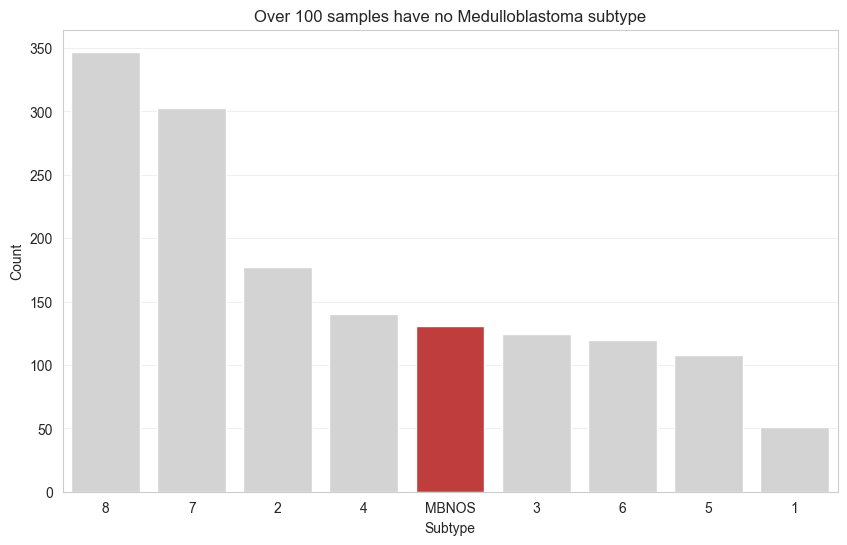

In [4]:
subtype_counts = sample_metadata['subtype'].value_counts()

colours = ['tab:red' if x == 'MBNOS' else 'lightgrey' for x in subtype_counts.index]

sns.barplot(x=subtype_counts.index, y=subtype_counts.values, palette=colours)
plt.title('Over 100 samples have no Medulloblastoma subtype')
plt.xlabel('Subtype')
plt.ylabel('Count');


In [5]:
# Display the subtype counts

sample_metadata['subtype'].value_counts(normalize=True)

subtype
8        0.231179
7        0.201865
2        0.117921
4        0.093271
MBNOS    0.087275
3        0.082612
6        0.079947
5        0.071952
1        0.033977
Name: proportion, dtype: float64

In [6]:
# Drop samples with missing subtypes and convert subtype to integer
sample_metadata_with_subtype = sample_metadata[sample_metadata['subtype'] != 'MBNOS']
sample_metadata_with_subtype['subtype'] = sample_metadata_with_subtype['subtype'].astype('int')

In [7]:
# Create platform-specific subsets
# GPL21145 = EPIC (850K), GPL13534 = HM450 (450K)
epic_meta = sample_metadata_with_subtype[sample_metadata_with_subtype["platform"] == "GPL21145"]
hm450_meta = sample_metadata_with_subtype[sample_metadata_with_subtype["platform"] == "GPL13534"]

# Define valid sample lists for filtering downstream
# Pre-existing beta values use title e.g. '9407201026_R06C01' as the id
valid_hm450_samples = sample_metadata_with_subtype['title']

# Data processed in Pylluminator for EPIC use GSM e.g. 'GSM3877765' as the id
valid_epic_samples = epic_meta['gsm']

print(f"Metadata loaded. Total samples: {len(sample_metadata)}")
print(f"- Samples with Medulloblastoma subtypes identified: {len(sample_metadata_with_subtype)}")
print(f" - EPIC (850k) samples expected: {len(epic_meta)}")
print(f" - HM450 (450k) samples expected: {len(hm450_meta)}")

Metadata loaded. Total samples: 1501
- Samples with Medulloblastoma subtypes identified: 1370
 - EPIC (850k) samples expected: 99
 - HM450 (450k) samples expected: 1271


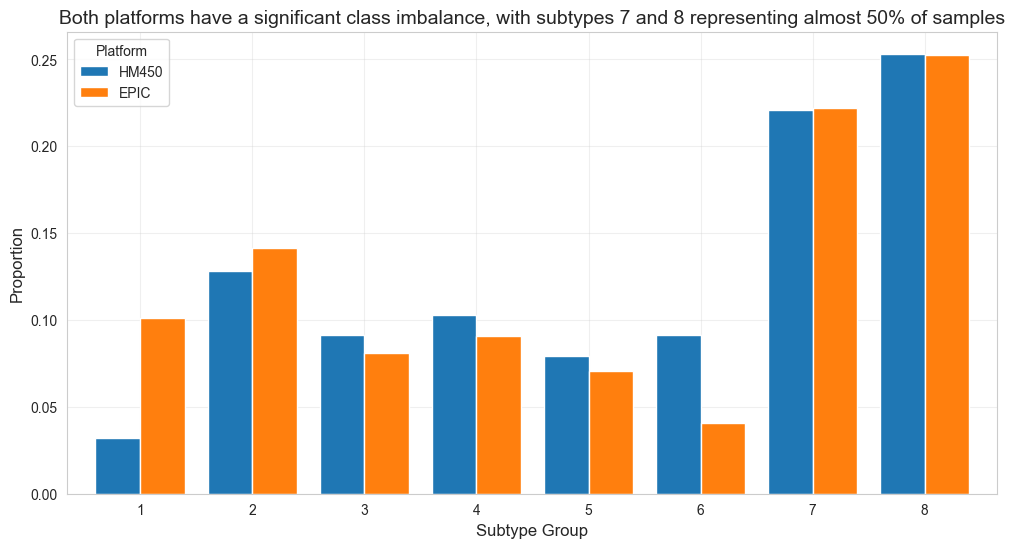

In [8]:
palette = sns.color_palette("tab10")

hm450_subtype_counts = hm450_meta['subtype'].value_counts(normalize=True)
epic_subtype_counts = epic_meta['subtype'].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'HM450': hm450_subtype_counts,
    'EPIC': epic_subtype_counts
})

ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8, color=[palette[0], palette[1]], rot=0)

# 3. Styling
plt.title('Both platforms have a significant class imbalance, with subtypes 7 and 8 representing almost 50% of samples', fontsize=14)
plt.ylabel('Proportion', fontsize=12)
plt.xlabel('Subtype Group', fontsize=12)
plt.legend(title='Platform');

## DNA Methylation Preprocessing

Next we import the raw .idat files and process the 110 EPIC samples using `pylluminator`<sup>3</sup>. The raw idata files were downloaded using `wget` from the GEO (Appendix A) and the sample sheet was generated using `pylluminator` (Appendix B).

`pylluminator` follows the pre-processing pipeline designed by SeSAMe<sup>4</sup>, in particular making a few key design decisions that differentiate it from the protocol applied using `minfi` in the original studies<sup>2, 5</sup>: using NOOB (Normal-exponential Out-Of-Band) noise reduction, non-linear dye bias correction and pOObah signal detection.

This method has proven to be better at handling noisy signal data common in cancer data<sup>4</sup>, and they make the peaks around 0 and 1 more prominent. This can be seen in the Betas density plots before and after the preprocessing pipeline has been applied, where the middle has been flattened and the positive peak has become more concentrated around 0.9.

SNPs, sex chromosomes and low quality probes were masked according to the quality standard defined by Zhou et al.<sup>6</sup>. Probes with a p-value of over 0.05 were also masked; 0.05 is a standard threshold<sup>7</sup> and the `pylluminator` default.

The ultimate goal of these preprocessing steps is to separate signal from noise: identifying if the flourescence intensity captured is a true biological reading or noise from technical errors or biological confounders.

In [9]:
# Loading the EPIC samples

my_samples = Samples.load(epic_samples_load_path)
my_samples.sample_sheet = my_samples.sample_sheet.merge(epic_meta, left_on='sample_id', right_on='gsm', how='left')

INFO:pylluminator.utils:Loading <class 'pylluminator.samples.Samples'> object from data/epic/epic_raw_samples


INFO:pylluminator.utils:Calculate beta values


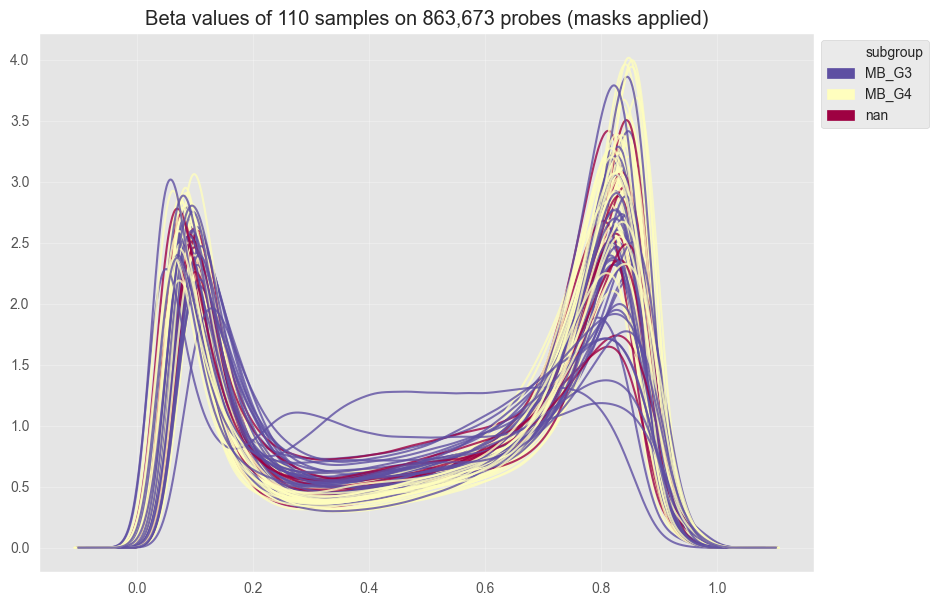

In [10]:
# Check the distribution of the betas across the samples before any processing

my_samples.calculate_betas(include_out_of_band=True)
betas_density(my_samples, color_column='subgroup')

In [11]:
# Masking the probes, inferring the type I channel, identifying probes with a p-value of over 0.05, 
# applying background correction and removing the dye bias.

my_samples.mask_xy_probes()
my_samples.mask_snp_probes()
my_samples.mask_quality_probes()

# Note this follows Sesame's order of operations, which differs from Pylluminator's paper
my_samples.infer_type1_channel()
my_samples.poobah()                  
my_samples.noob_background_correction() 
my_samples.dye_bias_correction_nl()

INFO:pylluminator.utils:Infer type I channel..
INFO:pylluminator.utils:start pOOBAH
INFO:pylluminator.utils:NOOB background correction..
INFO:pylluminator.utils:Non linear dye bias correction..


In [12]:
# Calculate the beta values

my_samples.calculate_betas(include_out_of_band=True)
epic_betas = my_samples.get_betas(apply_mask=True)
epic_betas.to_parquet(epic_betas_path)
print(f"Processed {my_samples.nb_samples} samples.")

INFO:pylluminator.utils:Calculate beta values


Processed 110 samples.


8

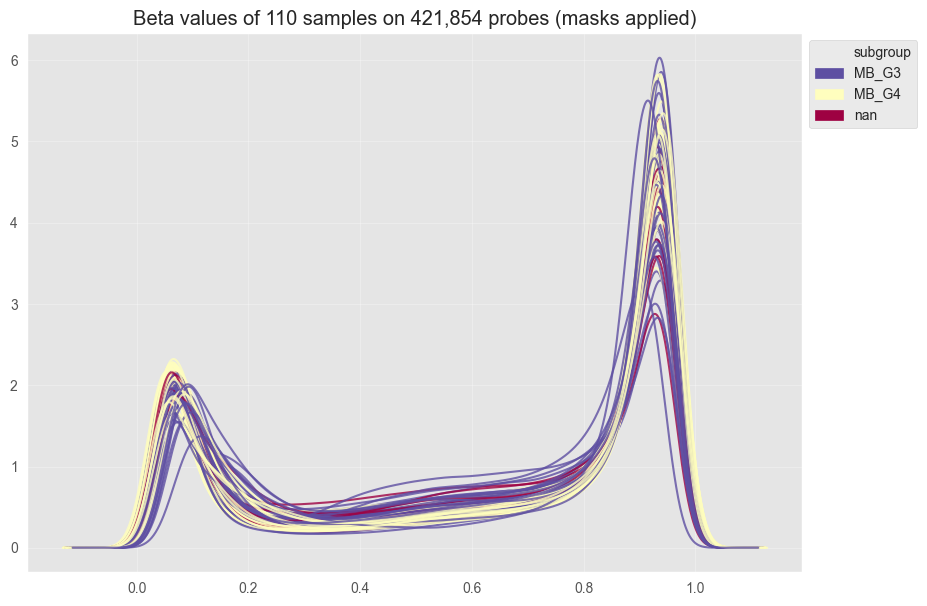

In [13]:
# Check the distribution of the betas across the samples after processing

betas_density(my_samples, color_column='subgroup')

del my_samples

# Cleanup memory
gc.collect()

In [14]:
# Reset style preferences after Pylluminator overrides them

sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (10, 6)

## Data Loading 

The `GSE130051_beta_values.csv` file was downloaded from GEO (Appendix A) and imported in chunks (Appendix C). The data is pre-loaded in parquet format here for memory efficiency. 

It contains the 1,501 samples that were pre-processed on the HM450. The 110 EPIC values we pre-processed are loaded here and aligned to the samples x probes structure.

In a side-by-side comparison for the same sample, we can see the pre-processing method used above pushes the Beta value distribution outwards to 0 and 1. 

In [15]:
files = sorted(glob.glob(f"{hm450_betas_pq_dir}/hm450_chunk_*.parquet"))
hm450_df = pd.concat([pd.read_parquet(f) for f in files], axis=1).T
hm450_df.index = hm450_df.index.str.replace('"', '', regex=False)
hm450_df.columns = hm450_df.columns.str.replace('"', '', regex=False)
hm450_df

probe_id,cg00050873,cg00212031,cg00213748,cg00214611,cg00455876,cg01707559,cg02004872,cg02011394,cg02050847,cg02233190,...,rs4742386,rs2857639,rs1495031,rs1510480,rs2468330,rs7746156,rs1945975,rs966367,rs877309,rs4331560
sample_id,,,,,,,,,,,,,,,,,,,,,
6026818126_R01C01,0.009330,0.008243,0.004481,0.007553,0.004471,0.217557,0.000356,0.421695,0.006337,0.036584,...,0.458060,0.515290,0.465874,0.027637,0.033455,0.023195,0.494100,0.025390,0.013985,0.018543
6026818126_R04C01,0.483423,0.006942,0.326877,0.013388,0.002171,0.204184,0.010453,0.003168,0.472581,0.001687,...,0.523918,0.548342,0.030543,0.426217,0.969368,0.467315,0.508202,0.495374,0.017112,0.419504
6026818136_R01C02,0.701815,0.000040,0.587043,0.003981,0.753882,0.075759,0.006859,0.880136,0.361917,0.012925,...,0.046951,0.659621,0.536803,0.413268,0.036919,0.032173,0.544994,0.501589,0.949576,0.435305
6164655140_R01C01,0.453227,0.033324,0.010995,0.198685,0.001171,0.222685,0.000757,0.957932,0.189382,0.000667,...,0.965914,0.942339,0.464304,0.033851,0.562314,0.517308,0.909249,0.887234,0.012645,0.461247
6164655140_R03C01,0.624980,0.000019,0.107690,0.000047,0.777034,0.041512,0.000031,0.924246,0.997453,0.006533,...,0.946673,0.140969,0.024771,0.377175,0.485798,0.963912,0.644601,0.118472,0.506912,0.954910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9305651054_R01C02,0.478928,0.011180,0.916513,0.006229,0.774014,0.047030,0.010084,0.985211,0.947561,0.009900,...,0.059037,0.061443,0.446432,0.028447,0.030742,0.035496,0.525168,0.446505,0.012938,0.036160
9305651055_R02C02,0.121639,0.215192,0.079596,0.288233,0.000638,0.196029,0.199795,0.187504,0.003904,0.149525,...,0.470217,0.085700,0.487223,0.471901,0.957911,0.446484,0.551768,0.430129,0.569985,0.036333
9305651095_R06C01,0.632298,0.000093,0.194851,0.030428,0.308076,0.113348,0.032437,0.903798,0.946936,0.005088,...,0.039880,0.559070,0.962943,0.407767,0.462119,0.427100,0.502763,0.024796,0.950351,0.036986


In [16]:
# Load EPIC probes from the preprocessed EPIC file [see Appendix D]
epic_df = (
    pd.read_parquet(epic_betas_path)
    .reset_index(drop=False)
    .set_index('probe_id')
    .drop(columns=['type', 'channel', 'probe_type'])
    .T
)

print(f"\n EPIC betas shape: {epic_df.shape}")


 EPIC betas shape: (110, 866519)


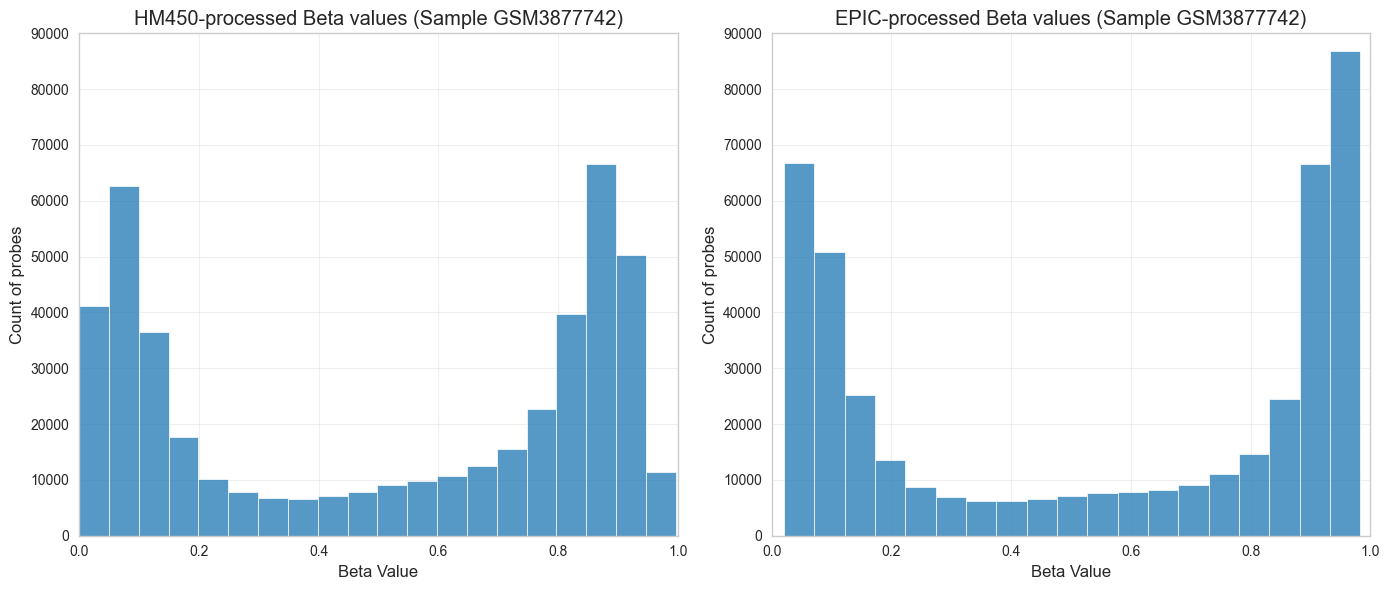

In [17]:
# Check the distribution of a single sample

gsm_id = 'GSM3877742'

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

overlapping_probes = hm450_df.columns.intersection(epic_df.columns)

hm450_test_sample = hm450_df.loc['200876170073_R07C01', overlapping_probes].astype(float)
epic_test_sample = epic_df.loc['GSM3877852', overlapping_probes].astype(float)

epic_only_samples_comparison = [hm450_test_sample, epic_test_sample]

for i, ax in enumerate(ax):
    sns.histplot(epic_only_samples_comparison[i], ax=ax, binwidth=0.05)
    ax.set_xlabel('Beta Value')
    ax.set_ylabel('Count of probes')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 90000)
    ax.set_title(f'HM450-processed Beta values (Sample {gsm_id})' if i == 0 else f'EPIC-processed Beta values (Sample {gsm_id})')

plt.tight_layout();

In [18]:
print(f'HM450: {hm450_test_sample.describe()}')
print(f'\nEPIC: {epic_test_sample.describe()}')

HM450: count    452482.000000
mean          0.511493
std           0.354713
min           0.000032
25%           0.109317
50%           0.613027
75%           0.860615
max           0.996596
Name: 200876170073_R07C01, dtype: float64

EPIC: count    434337.000000
mean          0.541094
std           0.375864
min           0.020510
25%           0.109494
50%           0.650959
75%           0.922248
max           0.983341
Name: GSM3877852, dtype: float64


## Data Preparation

After loading the datasets we filter the probes and samples, perform feature selection by ranking the top probes based on standard deviation (SD) and drop samples that fall below missingness thresholds.

The datasets were transformed in the following ways:

Dataset | Sample Counts | Feature Counts   |
------- | ------------- | ---------------- | 
HM450   | 1,501 -> 1,370| 453,152 -> 22,893| 
EPIC    | 110 -> 97     | 866,519 -> 22,893|

The HM450 samples had 0 missing values, while the EPIC samples had many (200,776). This will be partly due to the more aggressive noise reduction and signal detection procedures used in the SeSAMe method<sup>4</sup>.

We visualised the distribution of missing data in a matrix using `missingno` to assess whether data is Missing Completely at Random (MCAR) to determine whether to impute or drop data. The data was organised according to biological context (rows ordered by chromosome) and patient context (grouped by tumour subtype) to help identify patterns spacially. Thin vertical (samples) and horizontal (probes) confirmed that some data was Missing Not at Random (MNAR) and could not not be imputed.

There is significant variation in what is considered the acceptable threshold for dropping probes and samples, with some authors choosing a threshold of 5%<sup>7</sup> while others choose a threshold of 30%. We largely follow the procedure established in Abid and Rafiee's paper on the same dataset.<sup>8</sup>

- 2 EPIC samples were dropped as data was missing for more than 30% of probes and trying to impute that much data would introduce unjustifiable bias in the data. 
- Probes with more than 30% missing data were dropped also. 
- Probes with 100% missing values were directly replaced with the equivalent values from HM450.

For probes with < 30% missing values, we applied KNN and a form of Multiple Imputation by Chained Equations (MICE). We tested `MissForest` but it failed to converge in >90 mins on a dataset of this size,  In the model development and evaluation phase we can evaluate which is more effective, but for now we default to the MICE implementation as benchmarking suggests regression-based imputation performs significantly better.<sup>10</sup>

### Filtering Data

Filtering the probe data for CG probes, exclusion lists and the intersection with EPIC. Filtering the sample data to include only samples with identified Medulloblastoma subtypes.

In [19]:
array_type = ArrayType.HUMAN_450K  
genome_version = GenomeVersion.HG38  

hm450_anno = Annotations(array_type, genome_version)

probe_metadata = hm450_anno.probe_infos

probe_metadata = (
    probe_metadata[['probe_id', 'chromosome', 'mask_info', 'probe_type', 'genes', 'cgi']]
    .set_index('probe_id')
    .query('probe_type == "cg" and mask_info == "" and chromosome != "X" and chromosome != "Y" and chromosome != "chrX" and chromosome != "chrY" and chromosome != "M"')
)
probe_metadata['chromosome'] = probe_metadata['chromosome'].str.split('_').str[0].fillna(0).astype(int)
probe_metadata = probe_metadata.query('chromosome != 0')

INFO:pylluminator.utils:Dropping 64 probes with missing design type or channel


In [20]:
# Preview the probe metadata

probe_metadata

,chromosome,mask_info,probe_type,genes,cgi
probe_id,,,,,
cg00000029,16,,cg,RBL2,Shore
cg00000108,3,,cg,C3orf35,OpenSea
cg00000109,3,,cg,FNDC3B,OpenSea
cg00000165,1,,cg,NaN,Shore
cg00000236,8,,cg,VDAC3,OpenSea
...,...,...,...,...,...
cg27665925,19,,cg,AC008770.4;ZNF433-AS1,Island
cg27665985,15,,cg,RAB11A,OpenSea
cg27666046,17,,cg,SECTM1,Island


In [21]:
# Use probe metadata to filter out sex and quality control probes

probes_to_include = list(probe_metadata.index)

probe_mask = (
    hm450_df.columns.isin(epic_df.T.index.to_list()) & 
    hm450_df.columns.isin(probes_to_include)
)

# Define probes and samples to filter on
valid_hm450_probes = hm450_df.columns[probe_mask]

In [22]:
def filter_and_add_class_labels(df, valid_samples, valid_probes, df_index_column):
    '''
    Filter the dataframe on the valid samples and probes, add the class labels
    and set the GSM as the index.

    Valid samples are those with a Medulloblastoma subtype.

    Valid probes are those that are on both the HM450 and EPIC arrays, 
    and are not sex or quality control probes identified in the HM450 probe info.
    '''
    df = (
        df.loc[valid_samples, valid_probes]
        .merge(sample_metadata[['title', 'gsm', 'subtype']], left_index=True, right_on=df_index_column, how='left') 
        .set_index('gsm')
        .drop(columns=['title'])
    )
    return df

In [23]:
# Preparing the HM450 data

print(f"Original HM450 shape: {hm450_df.shape}")

# Filter probes and samples, add class labels, and use GSM as ID to match EPIC
hm450_prepped = filter_and_add_class_labels(hm450_df, valid_hm450_samples, valid_hm450_probes, 'title')

print(f"Final prepped shape: {hm450_prepped.shape}")

# Cleanup memory
gc.collect()

hm450_prepped

Original HM450 shape: (1501, 453152)
Final prepped shape: (1370, 438991)


,cg00000957,cg00001583,cg00002028,cg00002719,cg00002837,cg00003202,cg00003287,cg00004121,cg00007036,cg00007898,...,cg27634744,cg27648216,cg27656573,cg27657363,cg27657537,cg27660038,cg27662284,cg27662611,cg27665648,subtype
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.821513,0.020419,0.039951,0.000045,0.627149,0.006677,0.864179,0.399614,0.975427,0.000032,...,0.976499,0.051099,0.866739,0.134002,0.434325,0.077603,0.878265,0.066337,0.773707,8
GSM3876339,0.736347,0.000028,0.022311,0.009592,0.098019,0.005699,0.145974,0.459157,0.926608,0.000048,...,0.101945,0.053608,0.850016,0.795202,0.169859,0.084817,0.519539,0.090877,0.569179,2
GSM3876340,0.815611,0.028478,0.019097,0.000041,0.673058,0.006331,0.580937,0.581423,0.963881,0.000031,...,0.888857,0.661058,0.904304,0.675785,0.633877,0.087656,0.817524,0.055283,0.758996,4
GSM3876341,0.844299,0.021277,0.014207,0.025809,0.661987,0.000015,0.655122,0.492474,0.935201,0.003516,...,0.923401,0.660434,0.883825,0.865417,0.526852,0.086563,0.359593,0.050239,0.712351,2
GSM3876342,0.783373,0.004986,0.014756,0.000074,0.256857,0.000328,0.417514,0.602963,0.971769,0.004890,...,0.897578,0.042144,0.865492,0.794087,0.477546,0.087259,0.228936,0.043323,0.617420,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.822417,0.043014,0.071672,0.010787,0.814286,0.020752,0.814910,0.528810,0.937017,0.059299,...,0.897417,0.117582,0.919105,0.528781,0.712177,0.178295,0.771204,0.121184,0.836455,6
GSM3877853,0.836328,0.033505,0.059824,0.010339,0.769629,0.015487,0.749059,0.578885,0.946425,0.041219,...,0.898729,0.200801,0.880191,0.408714,0.381176,0.163201,0.841450,0.134100,0.829725,8
GSM3877854,0.681857,0.064631,0.134636,0.007381,0.331882,0.046807,0.663204,0.554315,0.917275,0.082894,...,0.866734,0.595693,0.903320,0.447514,0.691233,0.121702,0.824750,0.071894,0.792659,7


In [24]:
# Preparing the EPIC data

print(f"Original EPIC shape: {epic_df.shape}")

valid_epic_probes = hm450_prepped.drop(columns=['subtype']).columns

# Filter probes (matching HM450) and samples, and add class labels 
epic_prepped = filter_and_add_class_labels(epic_df, valid_epic_samples, valid_epic_probes, 'gsm')

print(f"Final prepped shape: {epic_prepped.shape}")

# Cleanup memory
gc.collect()

epic_prepped

Original EPIC shape: (110, 866519)
Final prepped shape: (99, 438991)


,cg00000957,cg00001583,cg00002028,cg00002719,cg00002837,cg00003202,cg00003287,cg00004121,cg00007036,cg00007898,...,cg27634744,cg27648216,cg27656573,cg27657363,cg27657537,cg27660038,cg27662284,cg27662611,cg27665648,subtype
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.698203,0.071432,0.087448,0.089336,0.846814,0.052403,0.811441,0.624103,0.942052,0.069157,...,0.907347,0.922728,0.952643,0.769178,0.927668,0.195525,0.871733,0.178538,0.961935,4
GSM3877746,0.846397,0.461303,0.048368,0.038740,0.857119,0.031384,0.825373,0.671264,0.958089,0.042043,...,0.945194,0.098204,0.954624,0.816396,0.614496,0.156064,0.939441,0.096892,0.928327,8
GSM3877747,0.770661,0.043389,0.053836,0.048646,0.863045,0.034079,0.742162,0.586516,0.954520,0.049381,...,0.918111,0.105964,0.938847,0.134382,0.661392,0.123614,0.932404,0.106321,0.895703,8
GSM3877748,0.784665,0.032086,0.042313,0.035343,0.817802,0.028810,0.720218,0.548430,0.966663,0.041490,...,0.946199,0.162408,0.952180,0.695024,0.429882,0.147110,0.921910,0.093735,0.864629,1
GSM3877749,0.716938,0.038511,0.050181,0.035283,0.451183,0.030298,0.685265,0.577239,0.955056,0.034763,...,0.930372,0.211861,0.961231,0.482997,0.421440,0.125052,0.885605,0.103502,0.797835,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.661909,0.055056,0.087713,0.072760,0.882379,0.051095,0.735617,0.590231,0.940074,0.076357,...,0.901663,0.171976,0.938048,0.471091,0.294768,0.147651,0.873376,NaN,0.936301,8
GSM3877851,0.767213,0.076263,0.095036,0.094568,0.178034,0.054506,0.779166,0.537707,0.944547,0.076559,...,0.889976,0.134941,0.949618,0.653040,0.340658,0.179397,0.854537,0.131903,0.919792,3
GSM3877852,0.795795,0.043883,0.055326,0.045330,0.869512,0.031464,0.820880,0.545902,0.951126,0.048842,...,0.940278,0.122141,0.964833,0.524199,0.752935,0.181150,NaN,0.116792,0.912075,6


### Feature Selection

We rank, sort and select the final probes to use based on SD. We identified the top 25k for the full HM450k dataset as the larger sample size would produce the more robust measurement of variance, and then we filtered the EPIC dataset to use identical probes.

In [25]:
# Calculate Median Absolute Deviation (MAD) for each probe and sort by MAD score

def sd_top_n(df, top_n=25000):
    subtypes = df['subtype']
    df = df.drop(columns=['subtype']).std(axis=0).sort_values(ascending=False)
    top_n_probes = df.head(top_n)
    top_n_probes['subtype'] = subtypes
    return top_n_probes

hm450_top_25k_probes = sd_top_n(hm450_prepped)
hm450_top_probes = hm450_prepped[hm450_top_25k_probes.index]
hm450_top_probes.to_parquet(hm450_top_probes_path)
hm450_top_probes 

,cg06833110,cg08782022,cg25900085,cg18924324,cg21211688,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,...,cg00650614,cg19516921,cg03014695,cg27241044,cg24135939,cg09966455,cg19259125,cg21957191,cg03660502,subtype
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.585194,0.011008,0.952265,0.070308,0.949534,0.005366,0.066601,0.275386,0.964099,0.003213,...,0.406990,0.412554,0.791206,0.536583,0.121929,0.304747,0.457189,0.828711,0.109480,8
GSM3876339,0.665192,0.909954,0.000065,0.990440,0.081500,0.802644,0.966922,0.980155,0.000087,0.014086,...,0.113226,0.182876,0.081682,0.184503,0.449365,0.053543,0.058733,0.061083,0.886559,2
GSM3876340,0.963114,0.982010,0.009828,0.108785,0.931986,0.929929,0.988755,0.951973,0.070918,0.966650,...,0.337685,0.699031,0.563932,0.971025,0.340028,0.926125,0.135956,0.629165,0.314500,4
GSM3876341,0.432923,0.879289,0.000043,0.904384,0.183378,0.617361,0.979156,0.121285,0.011801,0.996582,...,0.256914,0.213694,0.672095,0.249321,0.171495,0.361609,0.806767,0.323374,0.784429,2
GSM3876342,0.537229,0.871607,0.000050,0.993634,0.921940,0.598881,0.847534,0.800626,0.003304,0.895189,...,0.245070,0.095057,0.767597,0.540046,0.474663,0.461136,0.488142,0.468249,0.794581,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.606724,0.103484,0.925041,0.863483,0.868837,0.058963,0.108705,0.040272,0.776979,0.198909,...,0.723607,0.250669,0.908861,0.961205,0.791208,0.589144,0.276085,0.775802,0.783995,6
GSM3877853,0.556855,0.055812,0.816719,0.017160,0.927861,0.016829,0.114453,0.068071,0.851228,0.309515,...,0.481900,0.206303,0.862265,0.665536,0.161036,0.335036,0.743973,0.779546,0.793698,8
GSM3877854,0.951653,0.300885,0.484136,0.397636,0.895201,0.344391,0.854636,0.305975,0.059298,0.971110,...,0.610652,0.794567,0.760363,0.882579,0.576876,0.700534,0.310192,0.644501,0.617593,7


In [26]:
# Use the same top 25k probes for EPIC

epic_top_probes = epic_prepped[hm450_top_probes.columns]
epic_top_probes.to_parquet(epic_top_probes_path)
epic_top_probes

,cg06833110,cg08782022,cg25900085,cg18924324,cg21211688,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,...,cg00650614,cg19516921,cg03014695,cg27241044,cg24135939,cg09966455,cg19259125,cg21957191,cg03660502,subtype
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.929131,0.880765,0.792795,0.859588,0.862835,0.883948,0.897430,0.225301,0.139964,0.933569,...,0.208791,NaN,0.911222,0.856447,0.553164,0.523363,0.227670,0.482584,0.839335,4
GSM3877746,0.960283,0.445126,0.918020,0.925255,0.722853,0.550669,0.505484,0.046755,0.947862,0.632784,...,0.488427,NaN,0.910529,0.802893,0.433713,0.152878,0.959021,0.834220,0.717548,8
GSM3877747,0.056151,0.082874,0.877274,0.092775,0.934634,0.200870,0.056032,0.277040,0.823319,0.493752,...,0.608649,NaN,0.933678,0.603474,0.515209,0.439003,0.396682,0.897219,0.556732,8
GSM3877748,0.972257,0.887655,0.315499,0.951547,0.913043,0.903141,0.924024,0.487866,0.518681,0.848756,...,0.220704,0.797616,0.915404,0.923466,0.391372,0.577125,0.527921,0.640409,0.942372,1
GSM3877749,0.168119,0.096290,0.729617,0.076039,0.947205,0.498030,0.348018,0.112516,0.224159,0.964203,...,0.672484,NaN,0.940650,0.929251,0.438028,0.451667,0.463693,0.837258,0.300069,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.776426,0.111109,0.892450,0.107266,NaN,0.071427,0.069965,0.086436,0.915145,0.134739,...,0.507615,0.931704,0.899484,0.495587,0.167199,0.345286,0.775777,0.894072,0.655637,8
GSM3877851,0.109494,0.911012,0.152785,0.128882,0.848140,0.909418,0.893705,0.074218,0.111732,0.199838,...,0.194345,NaN,0.897447,0.734160,0.104318,0.223057,0.694115,0.456354,0.621857,3
GSM3877852,0.627091,0.073112,0.930719,0.911365,0.908457,0.049413,0.066521,0.061052,0.879851,0.119674,...,0.760736,NaN,0.944519,0.949653,0.856726,0.637030,0.270367,0.833130,0.876195,6


### Handling Missing Values

Detect the % of missing values per sample and per probe in both datasets. Visualise the distribution of missing data in a matrix and in histograms to assess the scale of missingness.

In [27]:
# Note that HM450 has no missing values

hm450_top_probes.isnull().sum().sort_values(ascending=False)

cg06833110    0
cg25588792    0
cg07189332    0
cg23820945    0
cg02234734    0
             ..
cg14218374    0
cg07795916    0
cg04191306    0
cg15568074    0
subtype       0
Length: 25001, dtype: int64

In [28]:
# Cleanup memory

del hm450_prepped, epic_prepped, hm450_top_probes
gc.collect()

0

In [29]:
# Meanwhile EPIC has some probes with 100% missing values

epic_completely_missing = epic_top_probes.isnull().mean() == 1
epic_empty_probes = epic_top_probes.loc[:, epic_completely_missing]
epic_empty_probes


,cg01097907,cg04804472,cg00362657,cg06644655,cg14535332,cg03703111,cg08287724,cg21167612,cg25540142,cg21006325,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 2500x1200 with 0 Axes>

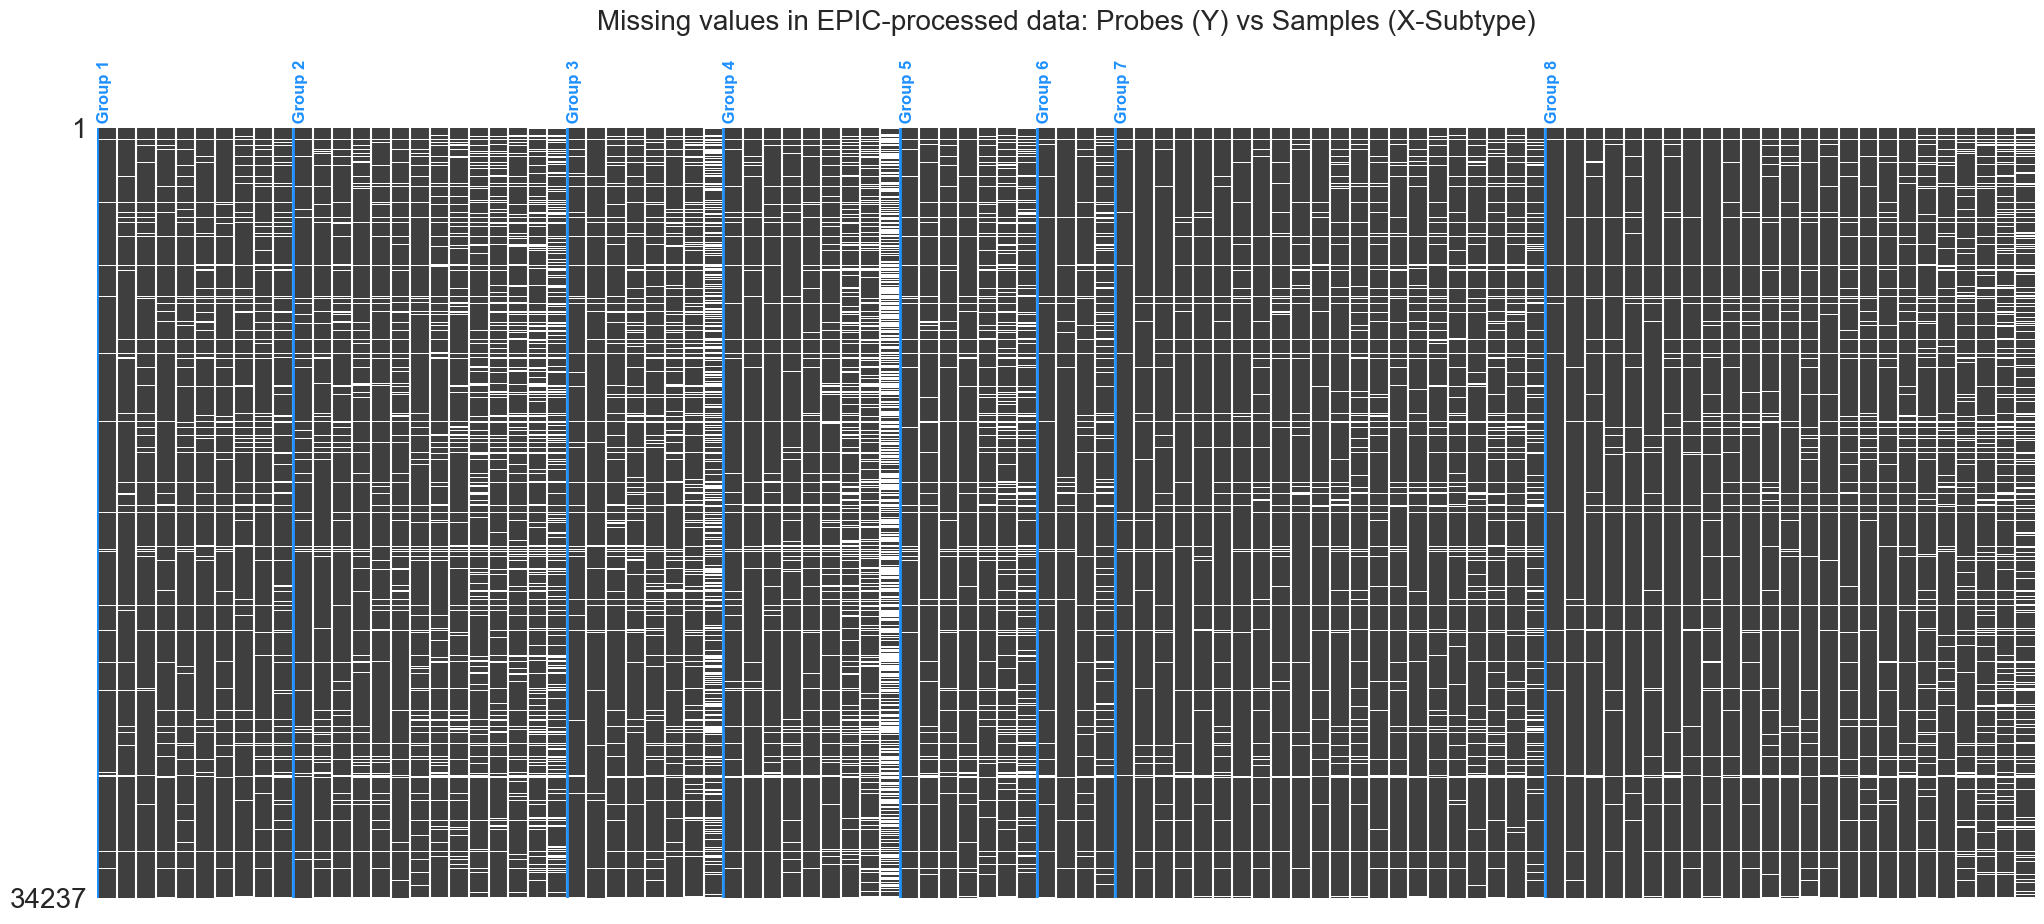

In [30]:
def sort_samples_by_subtype(df, meta_df):
    """Sorts dataframe rows (samples) by Subtype group, then by missingness."""
    gsm_to_subtype = meta_df.set_index('gsm')['subtype'].to_dict()
    missing_counts = df.isnull().sum(axis=1)
    
    return sorted(df.index, key=lambda x: (gsm_to_subtype.get(x, 999), missing_counts[x]))

def sort_probes_by_position(df, probe_metadata):
    """Sorts dataframe columns (probes) by Chromosome and Position."""
    probe_cols = [c for c in df.columns if c != 'subtype']
    current_info = probe_metadata.loc[probe_cols]
    sort_cols = ['chromosome', 'map_info'] if 'map_info' in current_info.columns else ['chromosome']

    return current_info.sort_values(sort_cols).index

sorted_samples = sort_samples_by_subtype(epic_top_probes, epic_meta)
sorted_probes = sort_probes_by_position(epic_top_probes, probe_metadata)

structured_data = epic_top_probes.loc[sorted_samples, sorted_probes].T

plt.figure(figsize=(25, 12)) 
ax = msno.matrix(structured_data, sparkline=False)

gsm_to_subtype = epic_meta.set_index('gsm')['subtype'].to_dict()
subtype_series = pd.Series([gsm_to_subtype.get(gsm, 999) for gsm in sorted_samples])

dividers = np.where(subtype_series != subtype_series.shift())[0]

for x in dividers:
    # Draw vertical line
    ax.axvline(x-0.5, color='dodgerblue', linewidth=2, linestyle='-')
    
    # Add label at the top of the column
    if x < len(sorted_samples):
        group_label = subtype_series.iloc[x]
        # Position text: x=index, y=0 (top of plot in msno)
        ax.text(x-0.5, 0, f' Group {group_label}', color='dodgerblue', 
                rotation=90, ha='left', va='bottom', fontweight='bold', fontsize=12)

plt.title('Missing values in EPIC-processed data: Probes (Y) vs Samples (X-Subtype)\n\n\n', fontsize=20);

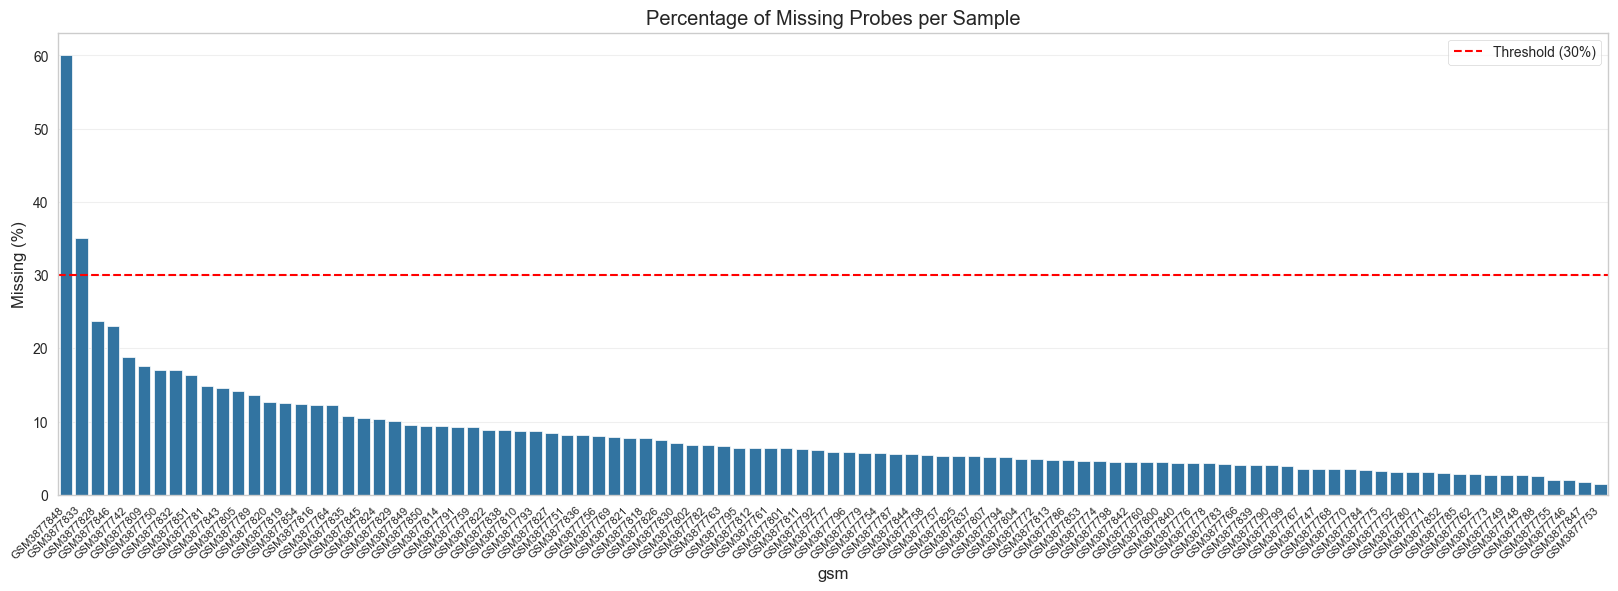

In [31]:
# Missingness per Sample

plt.figure(figsize=(20, 6))
sample_missing_pct = epic_top_probes.isnull().mean(axis=1) * 100
sample_missing_pct = sample_missing_pct.sort_values(ascending=False)
sns.barplot(x=sample_missing_pct.index, y=sample_missing_pct.values)
plt.title('Percentage of Missing Probes per Sample')
plt.ylabel('Missing (%)')
plt.axhline(y=30, color='red', linestyle='--', label='Threshold (30%)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.show()

In [32]:
# Sample Summary

print(f"Total Missing Values: {epic_top_probes.isnull().sum().sum()}")
print(f"Average Missingness per Sample: {sample_missing_pct.mean():.2f}%")

Total Missing Values: 200776
Average Missingness per Sample: 8.11%


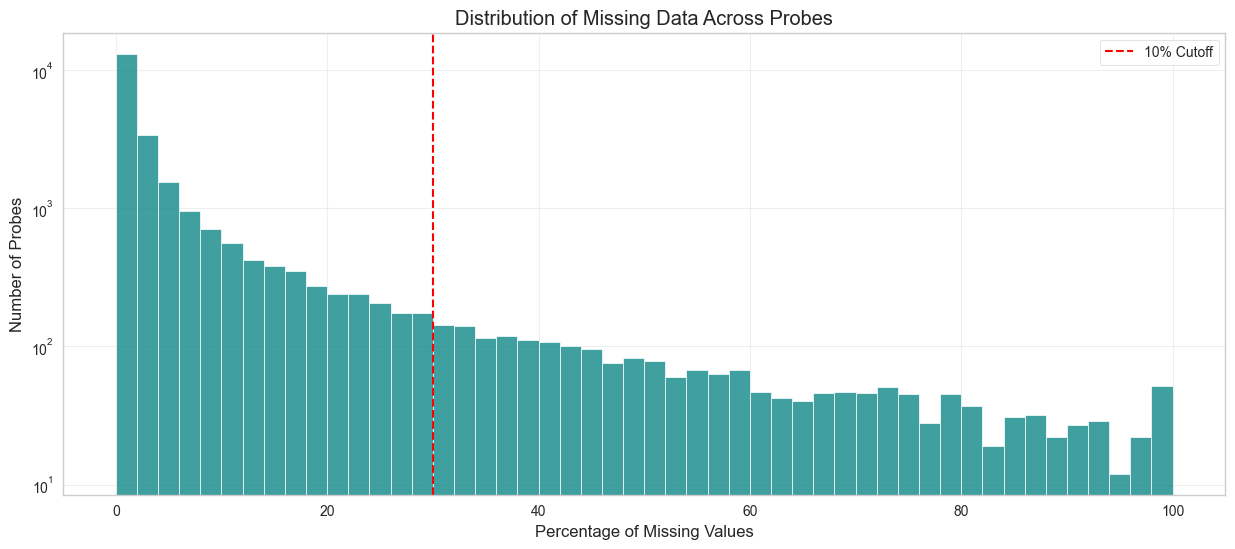

In [33]:
# Distribution of Missing Data Across Probes

probe_missing_pct = epic_top_probes.isnull().mean(axis=0) * 100

plt.figure(figsize=(15, 6))
sns.histplot(probe_missing_pct, bins=50, kde=False, color='teal')
plt.title('Distribution of Missing Data Across Probes')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Number of Probes')
plt.yscale('log')
plt.axvline(x=30, color='red', linestyle='--', label='10% Cutoff') # Common threshold
plt.legend()
plt.show()

In [34]:
# Probe summary statistics

print(f"Total Probes: {len(probe_missing_pct) - 1}")
print(f"Perfect Probes (0% missing): {(probe_missing_pct == 0).sum()} ({(probe_missing_pct == 0).mean():.1%})")
print(f'Probes Between 0% and 30% missing: {(probe_missing_pct.between(1, 30)).sum()} ({(probe_missing_pct.between(1, 30)).mean():.1%})')
print(f'Probes Between 30% and 100% missing: {(probe_missing_pct.between(30, 99)).sum()} ({(probe_missing_pct.between(30, 99)).mean():.1%})')
print(f"Completely Missing Probes (100% missing): {(probe_missing_pct == 100).sum()} ({(probe_missing_pct == 100).mean():.1%})")

Total Probes: 25000
Perfect Probes (0% missing): 8412 (33.6%)
Probes Between 0% and 30% missing: 14438 (57.7%)
Probes Between 30% and 100% missing: 2108 (8.4%)
Completely Missing Probes (100% missing): 43 (0.2%)


In [35]:
threshold = 0.3

print(f'Threshold: {threshold:.0%} missing\n')

sample_missing_pct = epic_top_probes.isnull().mean(axis=1)
samples_to_keep = sample_missing_pct[sample_missing_pct < 0.3].index

print(f"Initial Samples: {epic_top_probes.shape[0]}")
print(f"Dropped Samples: {epic_top_probes.shape[0] - len(samples_to_keep)}")

probe_missing_pct = epic_top_probes.isnull().mean(axis=0)
probes_to_keep = probe_missing_pct[probe_missing_pct < threshold].index

print(f"\nInitial Probes: {epic_top_probes.shape[1]-1}")
print(f"Probes Dropped: {epic_top_probes.shape[1] - len(probes_to_keep)}")

epic_cleaned = epic_top_probes.loc[samples_to_keep, probes_to_keep]


Threshold: 30% missing

Initial Samples: 99
Dropped Samples: 2

Initial Probes: 25000
Probes Dropped: 2151


### Imputing Missing Values

For the 55 values that with 100% of probes missing, we directly replaced them with matching beta values from the HM450-processed dataset of 97 identical samples. The shape of the distribution of an example sample `GSM3877742` is notably different due to the aforementioned differences in pre-processing methods. However the correlation between the two is still very strong (0.97) and we follow the procedure of Abid and Rafiee's paper.<sup>9</sup>

KNN and MICE were implemented for the remaining 13,640 probes with <30% missing values. Visual inspection of the distributions of random samples suggests they produce very similar results, and we will test performance of each in the model development phase.

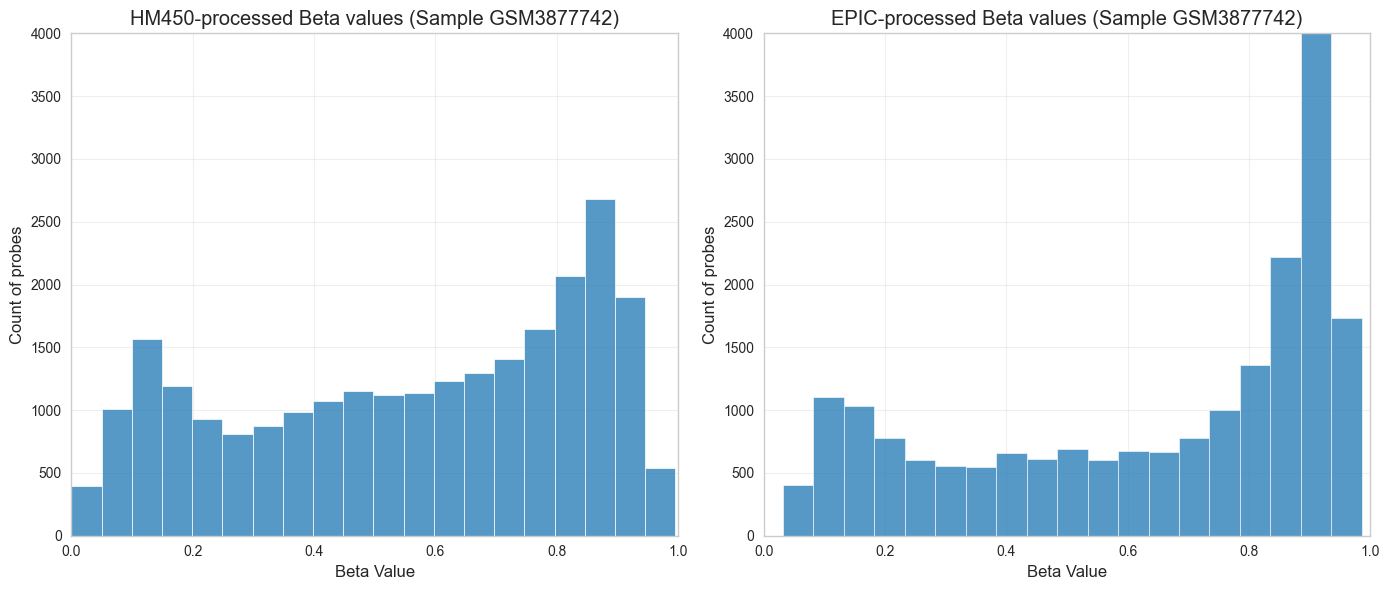

In [36]:
gsm_id = 'GSM3877742'

hm450_top_probes = pd.read_parquet(hm450_top_probes_path)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

hm450_test_sample = hm450_top_probes.drop(columns=['subtype']).loc[gsm_id].astype(float)
epic_test_sample = epic_top_probes.drop(columns=['subtype']).loc[gsm_id].astype(float)

epic_only_samples_comparison = [hm450_test_sample, epic_top_probes.loc[gsm_id].astype(float)]

for i, ax in enumerate(ax):
    sns.histplot(epic_only_samples_comparison[i], ax=ax, binwidth=0.05)
    ax.set_xlabel('Beta Value')
    ax.set_ylabel('Count of probes')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 4000)
    ax.set_title(f'HM450-processed Beta values (Sample {gsm_id})' if i == 0 else f'EPIC-processed Beta values (Sample {gsm_id})')

plt.tight_layout();

Spearman correlation:  0.95


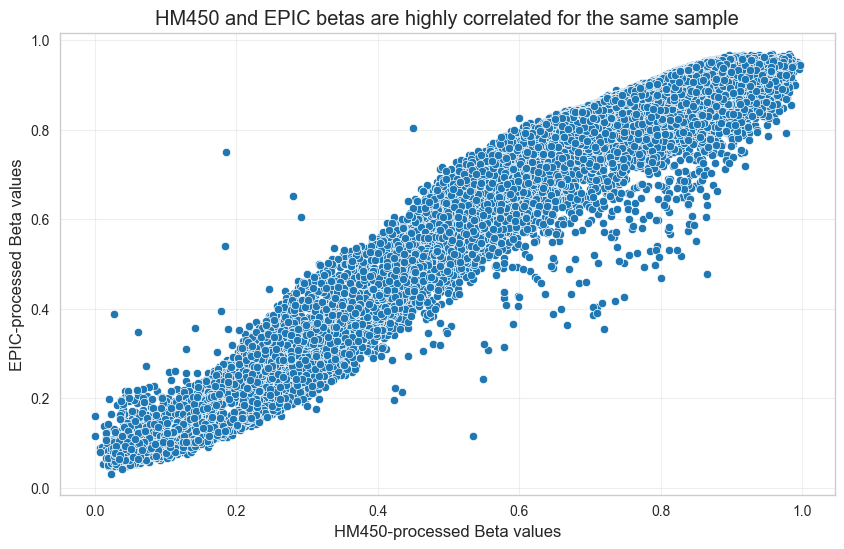

In [37]:
sns.scatterplot(x=hm450_test_sample, y=epic_test_sample)
plt.title(f'HM450 and EPIC betas are highly correlated for the same sample')
plt.xlabel('HM450-processed Beta values')
plt.ylabel('EPIC-processed Beta values')
print(f'Spearman correlation: {hm450_test_sample.corr(epic_test_sample, method="spearman"): .2f}')

In [38]:
# Display the probes that are 100% missing from EPIC

epic_empty_probes

,cg01097907,cg04804472,cg00362657,cg06644655,cg14535332,cg03703111,cg08287724,cg21167612,cg25540142,cg21006325,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GSM3877852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# Replace missing probes in EPIC with identical HM450 values

epic_cleaned_and_replaced = (
    epic_cleaned
    .merge(hm450_top_probes[epic_empty_probes.columns], left_index=True, right_index=True, how='left')
)

epic_cleaned_and_replaced[epic_empty_probes.columns]

,cg01097907,cg04804472,cg00362657,cg06644655,cg14535332,cg03703111,cg08287724,cg21167612,cg25540142,cg21006325,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.139249,0.838112,0.309996,0.981345,0.878295,0.855921,0.826010,0.884094,0.296314,0.821088,...,0.365285,0.655597,0.091525,0.396778,0.584927,0.554176,0.683633,0.701563,0.401683,0.271771
GSM3877746,0.864532,0.547693,0.811904,0.905263,0.806901,0.129572,0.895595,0.840360,0.718197,0.814852,...,0.848229,0.896746,0.607623,0.459325,0.624650,0.934708,0.746521,0.314761,0.746116,0.435994
GSM3877747,0.908609,0.132399,0.170193,0.388890,0.723945,0.175871,0.801605,0.960892,0.720674,0.077331,...,0.859130,0.722793,0.171472,0.320480,0.779779,0.954344,0.743552,0.545718,0.623693,0.237438
GSM3877748,0.672956,0.592809,0.179729,0.724280,0.039329,0.226085,0.053138,0.410694,0.584169,0.852693,...,0.687409,0.543785,0.076941,0.375633,0.703861,0.656104,0.429989,0.476763,0.528854,0.512916
GSM3877749,0.811408,0.463982,0.168631,0.903691,0.587404,0.522176,0.707609,0.907021,0.640143,0.250175,...,0.866651,0.709357,0.180203,0.180749,0.646629,0.946192,0.788168,0.486913,0.276860,0.327383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.857667,0.308873,0.647562,0.136823,0.076122,0.115776,0.235289,0.862170,0.845409,0.391525,...,0.880383,0.878292,0.145133,0.270071,0.734527,0.931015,0.554970,0.080428,0.793558,0.179217
GSM3877851,0.096471,0.846357,0.054516,0.521144,0.081630,0.014916,0.320262,0.115579,0.191171,0.703336,...,0.434507,0.325950,0.175204,0.313546,0.139802,0.259813,0.533127,0.117860,0.009805,0.262951
GSM3877852,0.827866,0.244957,0.465641,0.939166,0.561289,0.368485,0.671163,0.972092,0.798743,0.413279,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774


In [40]:
# Illustrate 1:1 match between HM450 and EPIC for the missing probes on the same sample

hm450_top_probes.loc[epic_cleaned_and_replaced.index, epic_empty_probes.columns]

,cg01097907,cg04804472,cg00362657,cg06644655,cg14535332,cg03703111,cg08287724,cg21167612,cg25540142,cg21006325,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.139249,0.838112,0.309996,0.981345,0.878295,0.855921,0.826010,0.884094,0.296314,0.821088,...,0.365285,0.655597,0.091525,0.396778,0.584927,0.554176,0.683633,0.701563,0.401683,0.271771
GSM3877746,0.864532,0.547693,0.811904,0.905263,0.806901,0.129572,0.895595,0.840360,0.718197,0.814852,...,0.848229,0.896746,0.607623,0.459325,0.624650,0.934708,0.746521,0.314761,0.746116,0.435994
GSM3877747,0.908609,0.132399,0.170193,0.388890,0.723945,0.175871,0.801605,0.960892,0.720674,0.077331,...,0.859130,0.722793,0.171472,0.320480,0.779779,0.954344,0.743552,0.545718,0.623693,0.237438
GSM3877748,0.672956,0.592809,0.179729,0.724280,0.039329,0.226085,0.053138,0.410694,0.584169,0.852693,...,0.687409,0.543785,0.076941,0.375633,0.703861,0.656104,0.429989,0.476763,0.528854,0.512916
GSM3877749,0.811408,0.463982,0.168631,0.903691,0.587404,0.522176,0.707609,0.907021,0.640143,0.250175,...,0.866651,0.709357,0.180203,0.180749,0.646629,0.946192,0.788168,0.486913,0.276860,0.327383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.857667,0.308873,0.647562,0.136823,0.076122,0.115776,0.235289,0.862170,0.845409,0.391525,...,0.880383,0.878292,0.145133,0.270071,0.734527,0.931015,0.554970,0.080428,0.793558,0.179217
GSM3877851,0.096471,0.846357,0.054516,0.521144,0.081630,0.014916,0.320262,0.115579,0.191171,0.703336,...,0.434507,0.325950,0.175204,0.313546,0.139802,0.259813,0.533127,0.117860,0.009805,0.262951
GSM3877852,0.827866,0.244957,0.465641,0.939166,0.561289,0.368485,0.671163,0.972092,0.798743,0.413279,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774


In [41]:
# Impute the missing values using KNNImputer for the remaining 14,438 probes with <30% missing values

imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

knn_imputed_epic = imputer.fit_transform(epic_cleaned_and_replaced)
knn_imputed_epic = pd.DataFrame(knn_imputed_epic, columns=epic_cleaned_and_replaced.columns, index=epic_cleaned_and_replaced.index)
knn_imputed_epic.to_parquet(knn_imputed_epic_path)
knn_imputed_epic


,cg06833110,cg08782022,cg25900085,cg18924324,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,cg14606586,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.929131,0.880765,0.792795,0.859588,0.883948,0.897430,0.225301,0.139964,0.933569,0.071314,...,0.365285,0.655597,0.091525,0.396778,0.584927,0.554176,0.683633,0.701563,0.401683,0.271771
GSM3877746,0.960283,0.445126,0.918020,0.925255,0.550669,0.505484,0.046755,0.947862,0.632784,0.767979,...,0.848229,0.896746,0.607623,0.459325,0.624650,0.934708,0.746521,0.314761,0.746116,0.435994
GSM3877747,0.056151,0.082874,0.877274,0.092775,0.200870,0.056032,0.277040,0.823319,0.493752,0.532992,...,0.859130,0.722793,0.171472,0.320480,0.779779,0.954344,0.743552,0.545718,0.623693,0.237438
GSM3877748,0.972257,0.887655,0.315499,0.951547,0.903141,0.924024,0.487866,0.518681,0.848756,0.213297,...,0.687409,0.543785,0.076941,0.375633,0.703861,0.656104,0.429989,0.476763,0.528854,0.512916
GSM3877749,0.168119,0.096290,0.729617,0.076039,0.498030,0.348018,0.112516,0.224159,0.964203,0.048914,...,0.866651,0.709357,0.180203,0.180749,0.646629,0.946192,0.788168,0.486913,0.276860,0.327383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.776426,0.111109,0.892450,0.107266,0.071427,0.069965,0.086436,0.915145,0.134739,0.863409,...,0.880383,0.878292,0.145133,0.270071,0.734527,0.931015,0.554970,0.080428,0.793558,0.179217
GSM3877851,0.109494,0.911012,0.152785,0.128882,0.909418,0.893705,0.074218,0.111732,0.199838,0.073087,...,0.434507,0.325950,0.175204,0.313546,0.139802,0.259813,0.533127,0.117860,0.009805,0.262951
GSM3877852,0.627091,0.073112,0.930719,0.911365,0.049413,0.066521,0.061052,0.879851,0.119674,0.771281,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774


In [42]:
# This setup is optimized for high-dimensional probe data

mice = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=20, n_jobs=-1),
    max_iter=3,
    n_nearest_features=250,  # CRITICAL: Limits the search space per column
    verbose=2, 
    random_state=42
)

mice_imputed_epic = mice.fit_transform(epic_cleaned_and_replaced)
mice_imputed_epic = pd.DataFrame(
    mice_imputed_epic, 
    columns=epic_cleaned_and_replaced.columns, 
    index=epic_cleaned_and_replaced.index)

mice_imputed_epic.to_parquet(mice_imputed_epic_path)
mice_imputed_epic

[IterativeImputer] Completing matrix with shape (97, 22893)
[IterativeImputer] Ending imputation round 1/3, elapsed time 832.68
[IterativeImputer] Change: 1031.4143257285984, scaled tolerance: 0.008 
[IterativeImputer] Ending imputation round 2/3, elapsed time 1654.93
[IterativeImputer] Change: 390.7043342378922, scaled tolerance: 0.008 
[IterativeImputer] Ending imputation round 3/3, elapsed time 2500.25
[IterativeImputer] Change: 318.05745360944417, scaled tolerance: 0.008 


,cg06833110,cg08782022,cg25900085,cg18924324,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,cg14606586,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.929131,0.880765,0.792795,0.859588,0.883948,0.897430,0.225301,0.139964,0.933569,0.071314,...,0.365285,0.655597,0.091525,0.396778,0.584927,0.554176,0.683633,0.701563,0.401683,0.271771
GSM3877746,0.960283,0.445126,0.918020,0.925255,0.550669,0.505484,0.046755,0.947862,0.632784,0.767979,...,0.848229,0.896746,0.607623,0.459325,0.624650,0.934708,0.746521,0.314761,0.746116,0.435994
GSM3877747,0.056151,0.082874,0.877274,0.092775,0.200870,0.056032,0.277040,0.823319,0.493752,0.532992,...,0.859130,0.722793,0.171472,0.320480,0.779779,0.954344,0.743552,0.545718,0.623693,0.237438
GSM3877748,0.972257,0.887655,0.315499,0.951547,0.903141,0.924024,0.487866,0.518681,0.848756,0.213297,...,0.687409,0.543785,0.076941,0.375633,0.703861,0.656104,0.429989,0.476763,0.528854,0.512916
GSM3877749,0.168119,0.096290,0.729617,0.076039,0.498030,0.348018,0.112516,0.224159,0.964203,0.048914,...,0.866651,0.709357,0.180203,0.180749,0.646629,0.946192,0.788168,0.486913,0.276860,0.327383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.776426,0.111109,0.892450,0.107266,0.071427,0.069965,0.086436,0.915145,0.134739,0.863409,...,0.880383,0.878292,0.145133,0.270071,0.734527,0.931015,0.554970,0.080428,0.793558,0.179217
GSM3877851,0.109494,0.911012,0.152785,0.128882,0.909418,0.893705,0.074218,0.111732,0.199838,0.073087,...,0.434507,0.325950,0.175204,0.313546,0.139802,0.259813,0.533127,0.117860,0.009805,0.262951
GSM3877852,0.627091,0.073112,0.930719,0.911365,0.049413,0.066521,0.061052,0.879851,0.119674,0.771281,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774


In [43]:
# Randomly sample 3 probes with different missingness levels

np.random.seed(random_state)

random_probe_high_missing_pct = probe_missing_pct[probe_missing_pct.between(0.2, 0.3)].sample(1)
random_probe_medium_missing_pct = probe_missing_pct[probe_missing_pct.between(0.1, 0.2)].sample(1)
random_probe_low_missing_pct = probe_missing_pct[probe_missing_pct.between(0.01, 0.1)].sample(1)


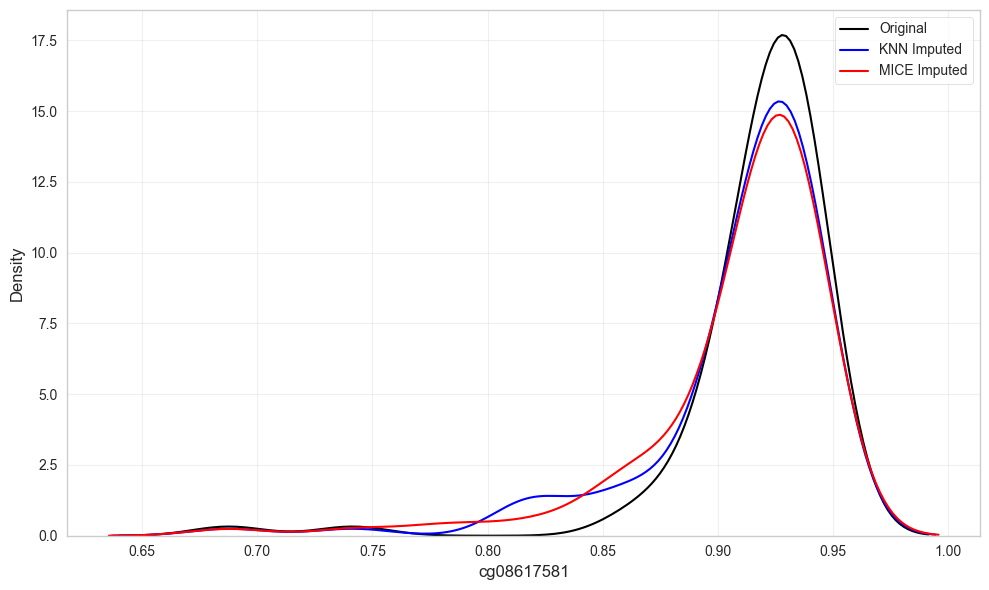

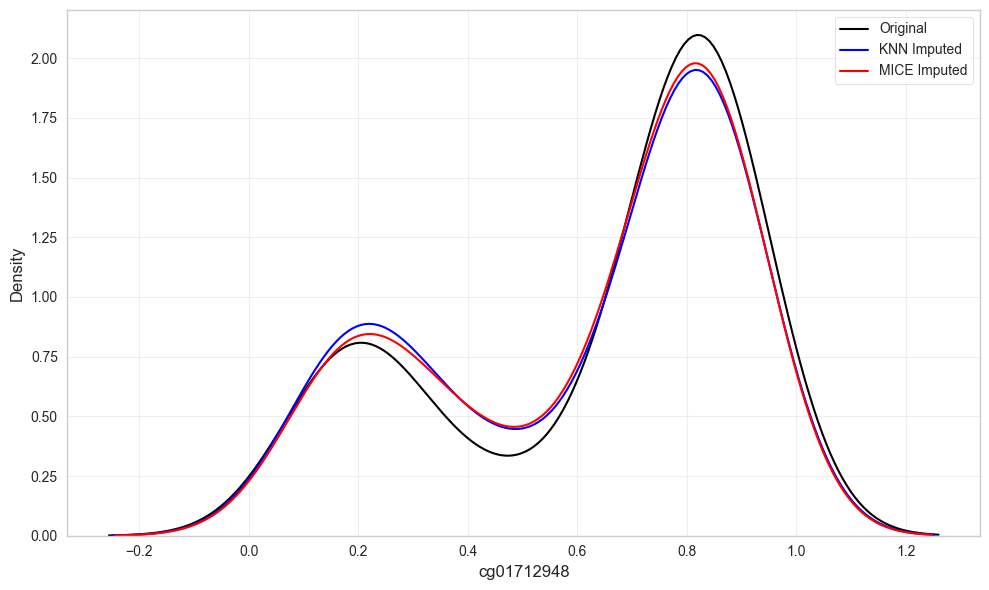

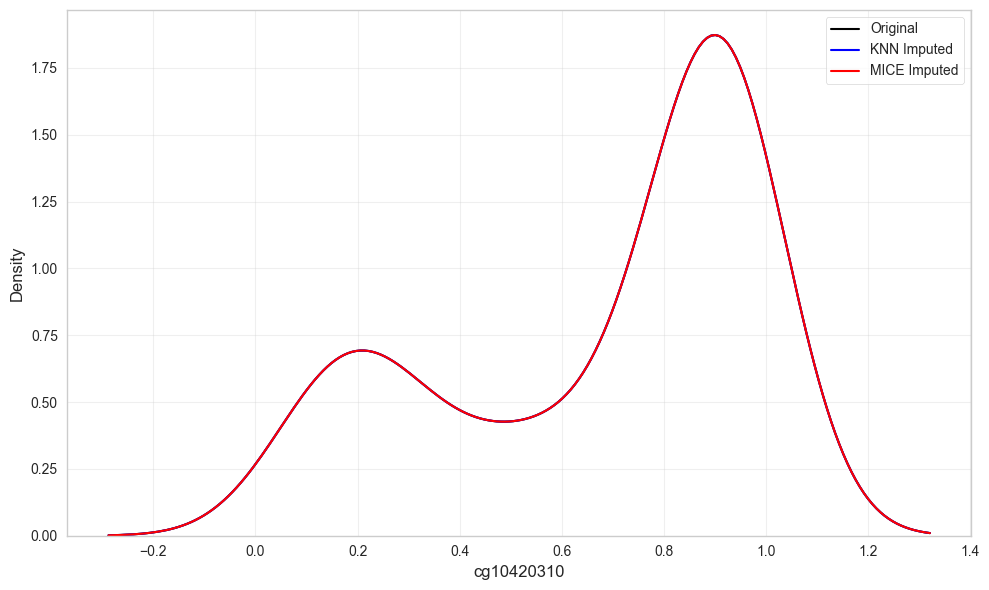

In [44]:
# Visualise the distribution of the imputed values compared to the original

for i, probe in enumerate([random_probe_high_missing_pct, random_probe_medium_missing_pct, random_probe_low_missing_pct]):
    
    sns.kdeplot(epic_cleaned_and_replaced.loc[:, probe.index[0]], label='Original', color='black')
    sns.kdeplot(knn_imputed_epic.loc[:, probe.index[0]], label='KNN Imputed', color='blue')
    sns.kdeplot(mice_imputed_epic.loc[:, probe.index[0]], label='MICE Imputed', color='red')
    plt.tight_layout()
    plt.legend()
    plt.show()

In [45]:
# Match to the final set of 22,893 columns in both datasets

hm450_final = hm450_top_probes[mice_imputed_epic.columns]
hm450_final

,cg06833110,cg08782022,cg25900085,cg18924324,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,cg14606586,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.585194,0.011008,0.952265,0.070308,0.005366,0.066601,0.275386,0.964099,0.003213,0.925236,...,0.765666,0.901646,0.000681,0.078268,0.368845,0.935924,0.924947,0.960384,0.585283,0.508766
GSM3876339,0.665192,0.909954,0.000065,0.990440,0.802644,0.966922,0.980155,0.000087,0.014086,0.005289,...,0.206654,0.311306,0.145043,0.598199,0.135943,0.108922,0.270451,0.395430,0.649667,0.121049
GSM3876340,0.963114,0.982010,0.009828,0.108785,0.929929,0.988755,0.951973,0.070918,0.966650,0.004424,...,0.623220,0.693172,0.659544,0.774480,0.622562,0.868721,0.917348,0.596964,0.390033,0.738974
GSM3876341,0.432923,0.879289,0.000043,0.904384,0.617361,0.979156,0.121285,0.011801,0.996582,0.010468,...,0.461277,0.361354,0.304467,0.748930,0.803449,0.925916,0.486513,0.766076,0.693428,0.348660
GSM3876342,0.537229,0.871607,0.000050,0.993634,0.598881,0.847534,0.800626,0.003304,0.895189,0.631810,...,0.888255,0.248915,0.846423,0.641511,0.176867,0.642114,0.621439,0.723099,0.676104,0.601927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.606724,0.103484,0.925041,0.863483,0.058963,0.108705,0.040272,0.776979,0.198909,0.746179,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774
GSM3877853,0.556855,0.055812,0.816719,0.017160,0.016829,0.114453,0.068071,0.851228,0.309515,0.621121,...,0.870412,0.843917,0.205629,0.330730,0.786886,0.940742,0.509974,0.145831,0.600746,0.450897
GSM3877854,0.951653,0.300885,0.484136,0.397636,0.344391,0.854636,0.305975,0.059298,0.971110,0.017394,...,0.751598,0.713955,0.202901,0.140326,0.775681,0.914529,0.720427,0.129702,0.362040,0.182436


## Dimensionality Reduction

After ranking the top 25,000 probes using standard deviation and filtering out the probes above the 30% missingness threshold in the EPIC dataset, we end up with a final set of 22,893 features to use in both the EPIC and HM450 datasets. 

We are now in a position to perform dimensionality reduction on this reduced feature set. We visualise the data with Principal Components Analysis (PCA) and Uniform Manifold Approximation and Projection (UMAP) to validate that our features are distinctive enough to separate the 8 tumour subtypes into distinct clusters, and we decompose the data into metagenes using Non-Negative Matrix Factorisation (NMF) to use in downstream model development.

First we perform min-max normalisation on the data as PCA is sensitive to feature scaling. Even though the Beta values are already bounded between 0 and 1, min-max scaling provides an extra layer of numerical stability. Crucially min-max scaling keeps the values bounded between 0 and 1 and meets the non-negativity criteria for NMF, which standardisation would not, while also preserving the original biological context.

The first three components from PCA explain 45% of the variance, which is just enough to separate the most distinct groups (e.g. 2 vs. 7) but struggles to differentiate between 2 and 3. 

Using the first 20 components with UMAP successfully separates each group into distinct clusters with minimal heterogeneity, and it also highlights broarder superstructures in the data: groups 1-4 form a supercluster, and groups 7 and 8 are the most distinct groups of all. This fits with Sharma et al.'s original classification<sup>1</sup> and is one of the strengths of UMAP: maintaining global structure<sup>11</sup>. For example:

> Of note, absolute separation between Grp3 and Grp4 was observed when using SNF on paired methylation and transcriptomic data, but was not observed when applying SNF to DNA-methylation data alone.

This is captured in UMAP with Group 3 and 4 being the two closest clusters. It also explains why they are almost indistinguishable from each other in PC1 and 2 from the NMF factorisation.

NMF has proven to be a successful technique to decompose thousnads of probes from DNA methylation data into a small subset of metagenes<sup>12</sup>. Using the cophenetic correlation we idenitifed `k=16` as the optimal number of metagenes to factorise the matrix into. 

The 3D PCA plot of the NMF metagenes showed a much clearer separation between groups 1-4 and groups 7 and 8, significantly improving on the original PCA projections and emulating much of the structure that was discovered in UMAP. 

The final dataset of `m` samples x `n` metagenes was exported to be used for the next phase of model development.

Note: NMF must be refit and feature selection (including additional selection using correlations to the target variable) need to be applied exclusively on training data in the model development pipeline for ICW2 to avoid data leakage. This process will then be applied to the training, validation and test sets as part of the full classification pipeline.

In [46]:
del hm450_top_probes, epic_top_probes, epic_cleaned
gc.collect()

16110

In [47]:
# Split the features and labels into separate datasets - in ICW2 we will extend this with a train/test split

X = hm450_final.drop(columns=['subtype'])
y = hm450_final['subtype']

# Apply min-max normalisation to the features
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

In [48]:
del X
gc.collect()

3934

### Principal Components Analysis (PCA)

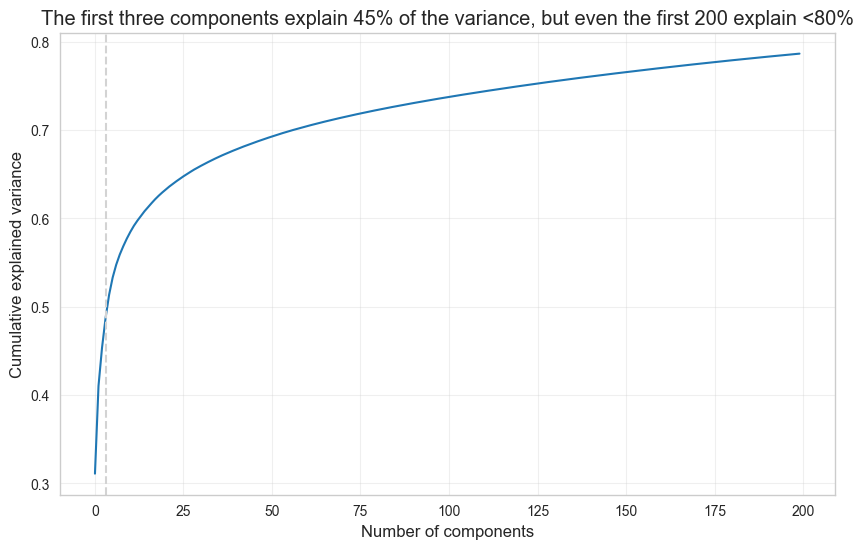

In [49]:
# Fit the PCA model
pca = PCA(n_components=200, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)

# Plot the cumulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axvline(x=3, color='lightgrey', linestyle='--', label='3 components')
plt.title("The first three components explain 45% of the variance, but even the first 200 explain <80%");

In [50]:
print(f'Cumulative explained variance of the first 20 components: {np.cumsum(pca.explained_variance_ratio_)[:20]}')

Cumulative explained variance of the first 20 components: [0.31107754 0.41037518 0.45373547 0.48729137 0.5136493  0.53309935
 0.5476141  0.55904883 0.5685656  0.5771571  0.5848251  0.5916946
 0.5975784  0.60293305 0.608183   0.6127895  0.61736596 0.6217408
 0.6257031  0.62935954]


In [51]:
# Plot the first three principal components in an interactive 3D plot
pca_3 = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3']).merge(y, left_index=True, right_index=True)

df = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df['subtype'] = y.reset_index(drop=True)
df = df.sort_values(by='subtype')

# Create a colour map for the subtypes to match between PCA and UMAP
tab10_hex = px.colors.qualitative.T10
unique_subtypes = sorted(df['subtype'].unique())
color_map = {label: tab10_hex[i % len(tab10_hex)] for i, label in enumerate(unique_subtypes)}

fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3',
                    color='subtype',
                    # Use color_discrete_map for dictionaries!
                    color_discrete_map=color_map, 
                    title='3D PCA separates the most distinct groups (e.g. 2 vs. 7) but struggles to differentiate between 2 and 3',
                    width=1000, height=700)

fig.update_traces(marker=dict(opacity=0.7, size=5))
fig.show()

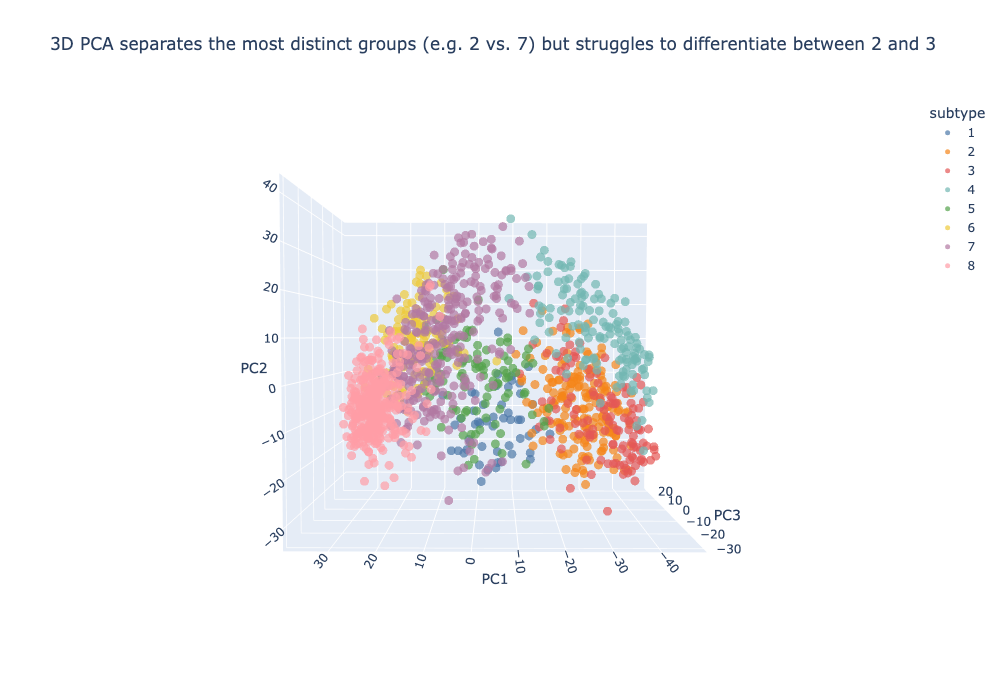

In [52]:
# Plot a static image of a fixed angle

from IPython.display import Image
Image('3D PCA.png')

### Uniform Manifold Approximation and Projection (UMAP)

In [53]:
# Fit the UMAP model

umap_model = UMAP(
    n_neighbors=10,
    min_dist=0.2,
    n_components=3,
    random_state=random_state
)

X_umap = umap_model.fit_transform(X_pca[:, :20])

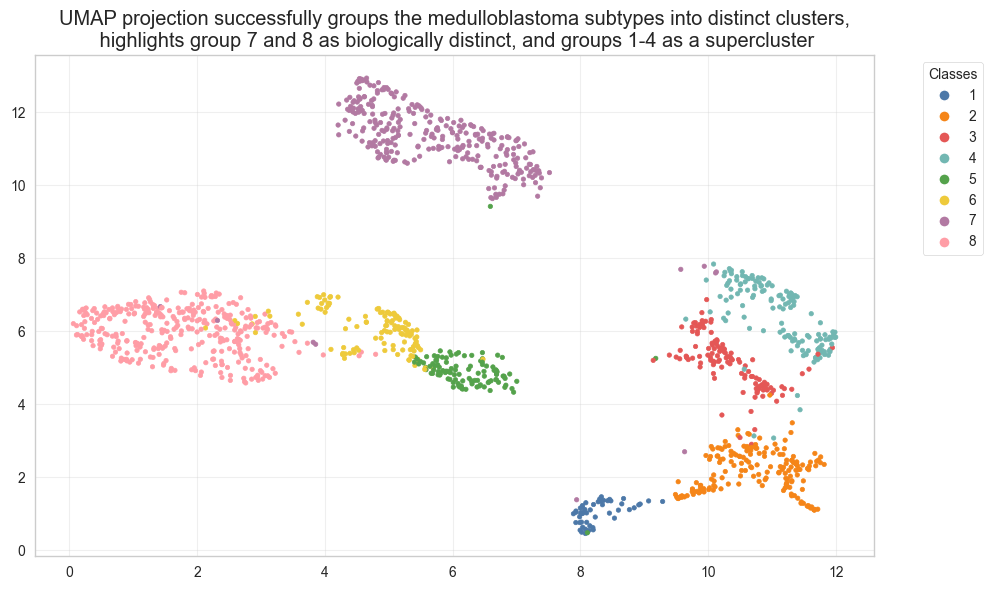

In [54]:
# Visualise the UMAP projection

umap_colors = [color_map[str(val)] for val in y]

plt.figure(figsize=(10, 6))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=umap_colors, # Your list of hex strings
    s=10
)

# Manually create legend handles to match the color_map
legend_handles = [
    Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=color_map[label], 
           markersize=8, label=str(label)) 
    for label in sorted(color_map.keys())
]

# Add the legend using these manual handles
plt.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP projection successfully groups the medulloblastoma subtypes into distinct clusters,\n highlights group 7 and 8 as biologically distinct, and groups 1-4 as a supercluster")
plt.tight_layout()
plt.show()

### Non-Negative Matrix Factorisation (NMF)

In [55]:
# Compute the cophenetic correlation for varying numbers of components

def compute_cophenetic(data, k):
    # Run NMF
    model = NMF(n_components=k, init='nndsvd', random_state=random_state, max_iter=1000)
    W = model.fit_transform(data) # Samples x Components
    
    # Identify which cluster each sample belongs to
    clusters = np.argmax(W, axis=1) # Length n_samples
    
    # Update consensus matrix: 1 if samples are in the same cluster
    consensus = (clusters[:, None] == clusters).astype(np.float32)
    
    # Calculate Cophenetic Correlation
    Z = linkage(consensus, method='average')
    c, coph_dists = cophenet(Z, pdist(consensus))
    return c

ks = [14, 15, 16, 17, 18, 19, 20]
scores = [compute_cophenetic(X_scaled, k) for k in ks]

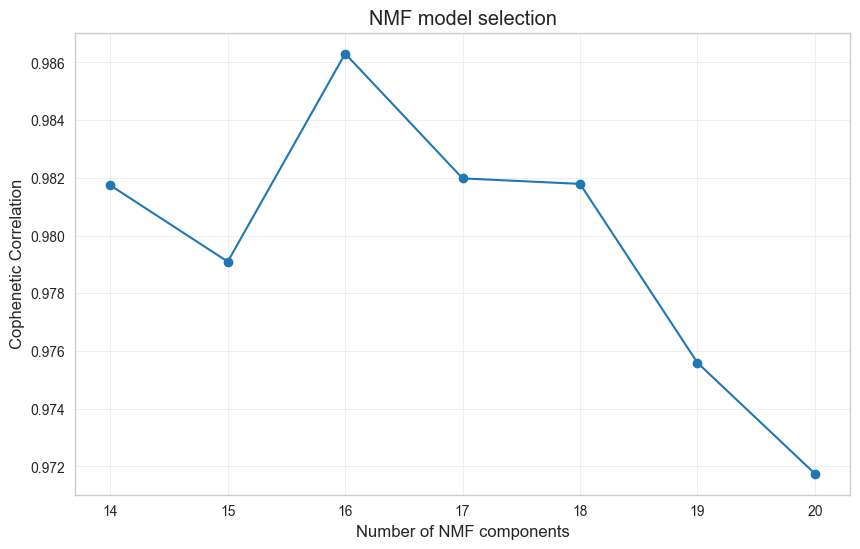

In [56]:
# Plot the cophenetic correlation for each number of components to select the optimal number of metagenes

plt.plot(ks, scores, marker="o")
plt.xlabel("Number of NMF components")
plt.ylabel("Cophenetic Correlation")
plt.title("NMF model selection")
plt.show()

In [57]:
# Implement NMF with the optimal number of components

K = 16

nmf = NMF(
    n_components=K,
    init="nndsvd",
    max_iter=1000,
    random_state=random_state
)

W = nmf.fit_transform(X_scaled)   # samples × components
H = nmf.components_               # components × CpGs

In [58]:
# Create a DataFrame of the NMF features

W_df = pd.DataFrame(
    W,
    index=X_scaled.index,
    columns=[f"NMF_{i+1}" for i in range(K)]
)

H_df = pd.DataFrame(
    H,
    index=[f"NMF_{i+1}" for i in range(K)],
    columns=X_scaled.columns
)

In [59]:
# Preview the NMF features for the first 5 samples
W_df.head()

,NMF_1,NMF_2,NMF_3,NMF_4,NMF_5,NMF_6,NMF_7,NMF_8,NMF_9,NMF_10,NMF_11,NMF_12,NMF_13,NMF_14,NMF_15,NMF_16
gsm,,,,,,,,,,,,,,,,
GSM3876338,0.393252,0.000000,0.014887,0.229396,0.087831,0.313838,0.000000,0.311838,0.172973,0.005357,0.000000,0.063054,0.283369,0.324102,0.000000,1.322342
GSM3876339,0.000000,0.000000,1.364072,0.000000,0.000000,0.000000,0.115880,0.200450,0.630129,0.000000,1.308340,0.000000,0.000000,0.172602,0.000000,0.000000
GSM3876340,0.231789,1.836254,0.279066,0.121367,0.965684,0.079168,1.545334,0.040234,0.097815,0.000000,0.114873,0.235309,0.000000,0.000000,0.277649,0.000000
GSM3876341,0.145244,0.020057,0.882890,0.325552,0.000000,0.077419,0.000000,0.569787,0.000000,0.000000,2.427887,0.094187,0.000000,0.699509,0.000000,0.036369
GSM3876342,0.302760,0.277120,1.407374,0.000000,0.182497,0.468447,0.056713,0.112088,0.000000,0.000000,1.456214,0.085807,0.007252,0.773463,0.000000,0.000000


In [60]:
# Review a statistical summary of the NMF components to identify broad differences between the metagenes

W_df.describe()

,NMF_1,NMF_2,NMF_3,NMF_4,NMF_5,NMF_6,NMF_7,NMF_8,NMF_9,NMF_10,NMF_11,NMF_12,NMF_13,NMF_14,NMF_15,NMF_16
count,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000,1370.000000
mean,0.318385,0.320422,0.233195,0.277261,0.186491,0.266751,0.542638,0.295368,0.275790,0.130286,0.262958,0.152387,0.204319,0.634233,0.279679,0.481507
std,0.293013,0.518058,0.469091,0.463130,0.269305,0.426721,1.011564,0.436864,0.584673,0.182648,0.459720,0.173276,0.348181,0.649104,0.602109,0.689324
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.062238,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016075,0.000000,0.000000
50%,0.266113,0.095296,0.015115,0.077158,0.064051,0.085830,0.054431,0.108862,0.055079,0.064817,0.060156,0.099458,0.048434,0.459202,0.000000,0.080918
75%,0.495422,0.407769,0.177815,0.332117,0.249962,0.329356,0.515498,0.382147,0.269122,0.187830,0.306102,0.235919,0.265769,1.020573,0.259541,0.905310
max,1.473310,2.806828,2.942671,2.749568,1.325776,2.249480,5.272734,2.315620,3.566705,1.100153,2.776611,1.009047,1.907722,3.055310,4.041754,2.251895


In [61]:
# Plot the first three principal components of the NMF features
pca_nmf = PCA(n_components=3)
W_pca = pca_nmf.fit_transform(W_df)

df = pd.DataFrame(W_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df['subtype'] = y.reset_index(drop=True)
df = df.sort_values(by='subtype')

fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3',
                    color='subtype',
                    # Use color_discrete_map for dictionaries!
                    color_discrete_map=color_map, 
                    title='3D PCA of NMF separates groups 1-4 and 7-8 much more than pure PCA',
                    width=1000, height=700)

fig.update_traces(marker=dict(opacity=0.7, size=5))
fig.show()

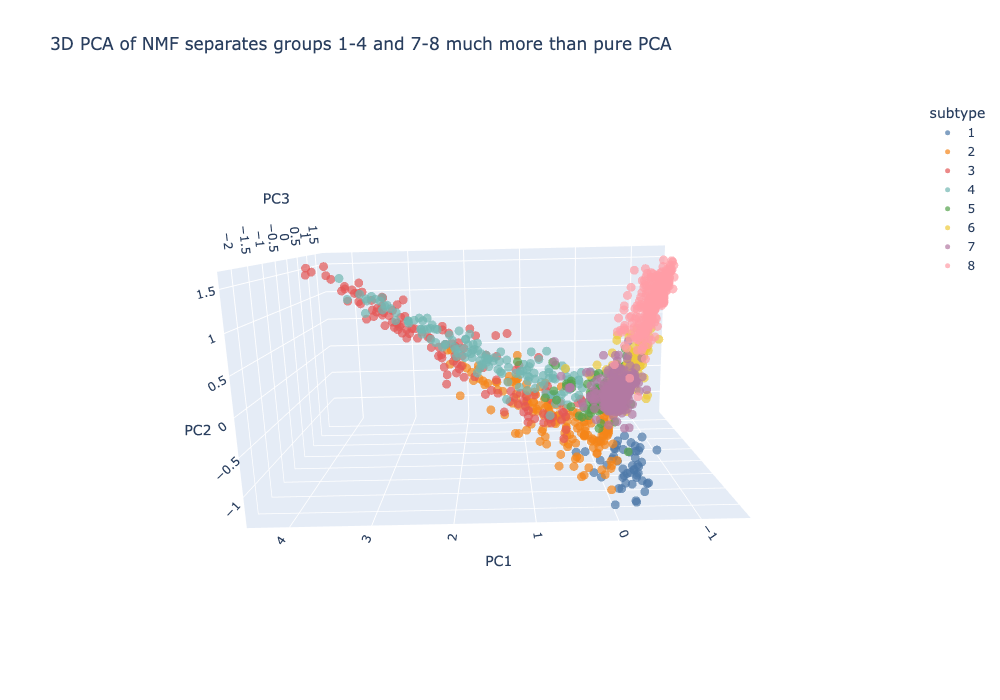

In [62]:
# Display static image of 3D PCA of NMF

Image('3D PCA NMF.png')

In [63]:
# Save the NMF features to a CSV file

final_dataset = W_df.copy()
final_dataset["Subtype"] = y

final_dataset.to_csv(nmf_path)

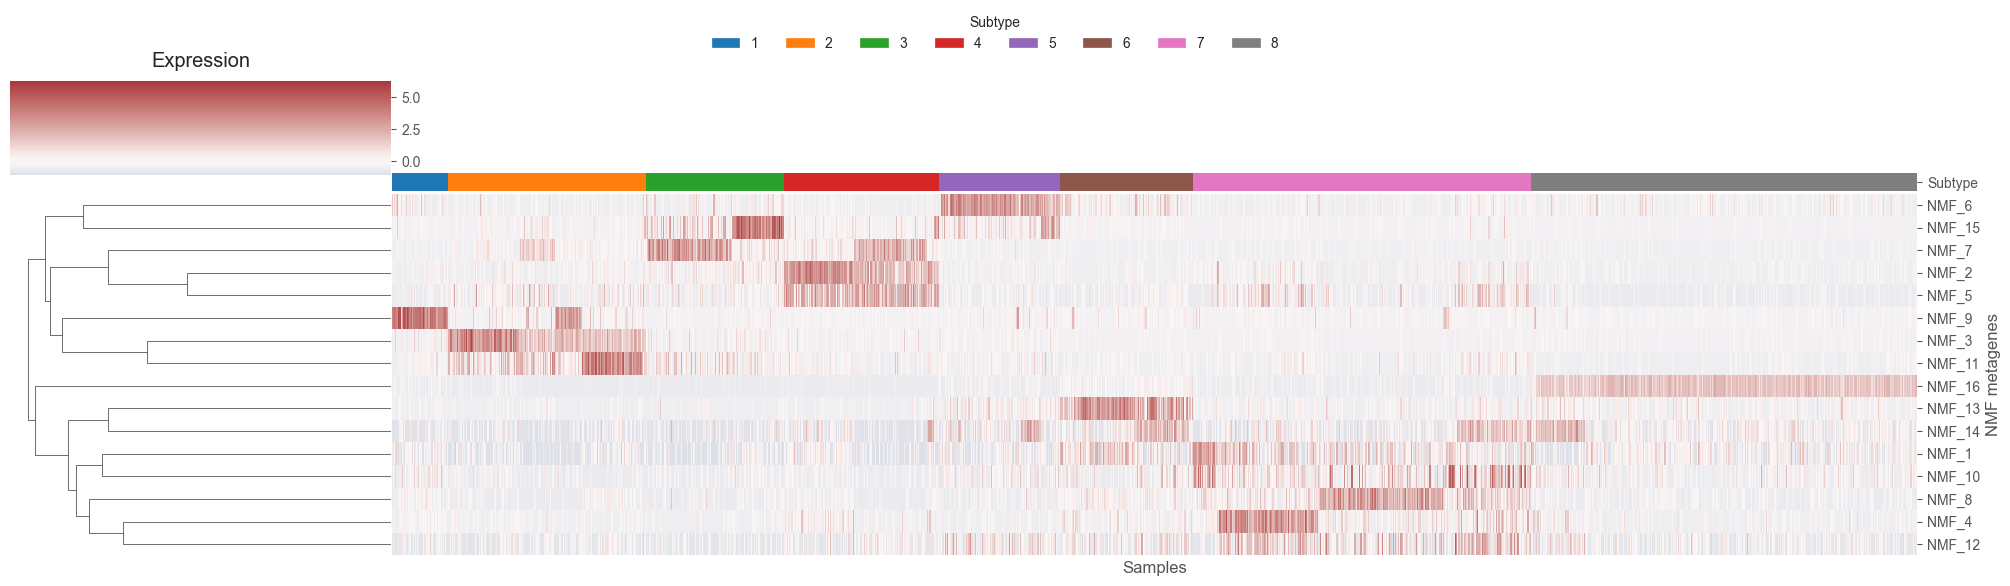

In [104]:
import matplotlib.patches as mpatches

# Plot a heatmap of the NMF features grouped by subtype

X = final_dataset.filter(like='NMF_')
meta = final_dataset['Subtype'].reset_index(drop=False).set_index('gsm')
X_z = (X - X.mean()) / X.std()

# Order samples by subtype, then by dominant metagene

dominant = X.values.argmax(axis=1)

order_df = meta.copy()
order_df["dominant"] = dominant

order = (
    order_df
    .sort_values(["Subtype", "dominant"])
    .index
)

X_ord = X_z.loc[order]
meta_ord = meta.loc[order]

# Create a palette for the subtypes

subtypes = meta_ord["Subtype"].astype(str)
palette = dict(
    zip(subtypes.unique(),
        sns.color_palette("tab10", 8))
)

col_colors = subtypes.map(palette)

# Plot the heatmap

g = sns.clustermap(
    X_ord.T,
    col_cluster=False,
    row_cluster=True,
    col_colors=col_colors,
    cmap="vlag",
    center=0,
    xticklabels=False,
    figsize=(20, 6)
)

# Axis labels
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("NMF metagenes")

# Legend colours and positions
handles = [
    mpatches.Patch(color=color, label=subtype)
    for subtype, color in palette.items()
]

g.fig.subplots_adjust(top=0.85)

g.fig.legend(
    handles=handles,
    title="Subtype",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=8,          # one column per subtype
    frameon=False
)

g.ax_col_colors.set_position([
    g.ax_col_colors.get_position().x0,
    g.ax_col_colors.get_position().y0,
    g.ax_col_colors.get_position().width,
    g.ax_col_colors.get_position().height * 1.3
])

g.cax.set_title("Expression", pad=10);

## References

1. Kool, M., Korshunov, A., Remke, M. et al. Molecular subgroups of medulloblastoma: an international meta-analysis of transcriptome, genetic aberrations, and clinical data of WNT, SHH, Group 3, and Group 4 medulloblastomas. Acta Neuropathol 123, 473–484 (2012). https://doi.org/10.1007/s00401-012-0958-8
2. Sharma, T., Schwalbe, E.C., Williamson, D. et al. Second-generation molecular subgrouping of medulloblastoma: an international meta-analysis of Group 3 and Group 4 subtypes. Acta Neuropathol 138, 309–326 (2019). https://doi.org/10.1007/s00401-019-02020-0
3. Elio Fanchon, Benjamin Loire, Jean-Philippe Trani, Frédérique Magdinier, Anaïs Baudot. Pylluminator: fast and scalable analysis of DNA methylation data in Python.  bioRxiv 2025.09.16.676547; doi: https://doi.org/10.1101/2025.09.16.676547
4. Zhou, W., Triche, T. J., Jr, Laird, P. W., & Shen, H. (2018). SeSAMe: reducing artifactual detection of DNA methylation by Infinium BeadChips in genomic deletions. Nucleic acids research, 46(20), e123. https://doi.org/10.1093/nar/gky691
5. Northcott, P., Buchhalter, I., Morrissy, A. et al. The whole-genome landscape of medulloblastoma subtypes. Nature 547, 311–317 (2017). https://doi.org/10.1038/nature22973
6. Wanding Zhou, Peter W. Laird, Hui Shen, Comprehensive characterization, annotation and innovative use of Infinium DNA methylation BeadChip probes, Nucleic Acids Research, Volume 45, Issue 4, 28 February 2017, Page e22, https://doi.org/10.1093/nar/gkw967
7. Zhang, W., Young, J. I., Gomez, L., Schmidt, M. A., Lukacsovich, D., Varma, A., Chen, X. S., Kunkle, B., Martin, E. R., & Wang, L. (2024). Critical evaluation of the reliability of DNA methylation probes on the Illumina MethylationEPIC v1.0 BeadChip microarrays. Epigenetics, 19(1), 2333660. https://doi.org/10.1080/15592294.2024.2333660
8. Abid, O. and Rafiee, G. (2025). Cross-Platform DNA Methylation Classifier for the Eight Molecular Subtypes of Group 3 & 4 Medulloblastoma https://doi.org/10.48550/arXiv.2510.02416
9. Zhang, W., Young, J. I., Gomez, L., Schmidt, M. A., Lukacsovich, D., Varma, A., Chen, X. S., Kunkle, B., Martin, E. R., & Wang, L. (2024). Critical evaluation of the reliability of DNA methylation probes on the Illumina MethylationEPIC v1.0 BeadChip microarrays. Epigenetics, 19(1), 2333660. https://doi.org/10.1080/15592294.2024.2333660 
10. Lena, P. D., Sala, C., Prodi, A., & Nardini, C. (2020). Methylation data imputation performances under different representations and missingness patterns. BMC bioinformatics, 21(1), 268. https://doi.org/10.1186/s12859-020-03592-5
11. McInnes et al., (2018). UMAP: Uniform Manifold Approximation and Projection. Journal of Open Source Software, 3(29), 861, https://doi.org/10.21105/joss.00861
12. Schwalbe, E. C., Lindsey, J. C., Nakjang, S., Crosier, S., Smith, A. J., Hicks, D., Rafiee, G., Hill, R. M., Iliasova, A., Stone, T., Pizer, B., Michalski, A., Joshi, A., Wharton, S. B., Jacques, T. S., Bailey, S., Williamson, D., & Clifford, S. C. (2017). Novel molecular subgroups for clinical classification and outcome prediction in childhood medulloblastoma: a cohort study. The Lancet. Oncology, 18(7), 958–971. https://doi.org/10.1016/S1470-2045(17)30243-7



## Appendices 

### Appendix A - Data Download

In [64]:
# Download raw TAR file (both platforms) and transposed beta values (HM450 only) using wget in the terminal

'''wget https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE130051&format=file
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130051/suppl/GSE130051_transposed_beta_values_GSE130051.csv.gz
'''

# Extract IDAT files from the raw tar file

'''print("\nChecking for supplementary files (IDATs)...")
tar_file = dest_path / "GSE130051_RAW.tar"

gz_files = list(dest_path.glob("**/*.idat.gz"))
if gz_files:
    print(f"Found {len(gz_files)} compressed .idat.gz files. Decompressing...")
    for gz_path in gz_files:
        try:
            # gunzip keeping original file name (stripping .gz)
            subprocess.run(["gunzip", "-k", "-f", str(gz_path)], check=True)
        except Exception as e:
            print(f"Failed to decompress {gz_path}: {e}")
    print("Decompression complete.")'''

'print("\nChecking for supplementary files (IDATs)...")\ntar_file = dest_path / "GSE130051_RAW.tar"\n\ngz_files = list(dest_path.glob("**/*.idat.gz"))\nif gz_files:\n    print(f"Found {len(gz_files)} compressed .idat.gz files. Decompressing...")\n    for gz_path in gz_files:\n        try:\n            # gunzip keeping original file name (stripping .gz)\n            subprocess.run(["gunzip", "-k", "-f", str(gz_path)], check=True)\n        except Exception as e:\n            print(f"Failed to decompress {gz_path}: {e}")\n    print("Decompression complete.")'

In [65]:
# Create lists of files for each platform

'''Function to construct filenames: {gsm}_{title}_{Color}.idat
def get_filenames(df):
    files = []
    # Iterate through rows and build both Red and Grn filenames
    for row in df.iter_rows(named=True):
        base_name = f"{row['gsm']}_{row['title']}"
        files.append(f"{base_name}_Grn.idat")
        files.append(f"{base_name}_Red.idat")
    return files

# Write the lists to text files
with open("epic_files.txt", "w") as f:
    f.write("\n".join(get_filenames(epic_meta)))

with open("hm450_files.txt", "w") as f:
    f.write("\n".join(get_filenames(hm450_meta)))

print(f"Created lists: {len(epic_df)*2} EPIC files and {len(hm450_df)*2} HM450 files.")'''

# Move files to appropriate folders in the terminal

'''# Create the destination folders`
mkdir -p data/EPIC data/HM450

# Move the EPIC files
# This reads the filenames from the text file and moves them from data/ into data/EPIC/
cat epic_files.txt | xargs -I {} mv data/{} data/EPIC/

# Move the HM450 files
cat hm450_files.txt | xargs -I {} mv data/{} data/HM450/'''

'# Create the destination folders`\nmkdir -p data/EPIC data/HM450\n\n# Move the EPIC files\n# This reads the filenames from the text file and moves them from data/ into data/EPIC/\ncat epic_files.txt | xargs -I {} mv data/{} data/EPIC/\n\n# Move the HM450 files\ncat hm450_files.txt | xargs -I {} mv data/{} data/HM450/'

### Appendix B - DNA Methylation Preprocessing

In [ ]:
epic_dir = 'data/EPIC'
my_samples = read_samples(epic_dir)
my_samples.save(epic_samples_load_path)

INFO:pylluminator.utils:>> start reading sample files from data/EPIC
INFO:pylluminator.utils:Found a samplesheet.csv file in data directory
INFO:pylluminator.utils:Use colum sample_name to label samples
INFO:pylluminator.utils:Dropping 68 probes with missing design type or channel
INFO:pylluminator.utils:Annotation auto-detected to be EPIC - genome version set to hg38
INFO:pylluminator.utils:Lost 87,996 illumina probes (4.18%) while merging information with Manifest
INFO:pylluminator.utils:Mask(name: min_beads_1, scope: sample GSM3877755, # masked probes: 0) has no masked probes, skipping it.
INFO:pylluminator.utils:reading sample files done, 110 samples found

INFO:pylluminator.utils:Saving <class 'pylluminator.samples.Samples'> object in data/EPIC/raw_samples


In [67]:
# Preview raw data before preprocessing
my_samples = Samples.load(epic_samples_load_path)
my_samples.get_signal_df()['GSM3877770']

INFO:pylluminator.utils:Loading <class 'pylluminator.samples.Samples'> object from data/epic/epic_raw_samples


signal_channel                           G                R         
methylation_state                        M        U       M        U
type channel probe_type probe_id                                    
I    G       cg         cg00000769   503.0   8604.0   725.0   1828.0
                        cg00000957  8568.0   2233.0  1691.0   2360.0
                        cg00002033  2813.0   6011.0   626.0    759.0
                        cg00002934   390.0  10423.0   546.0   1713.0
                        cg00003287  8899.0   3299.0   896.0    589.0
...                                    ...      ...     ...      ...
II   nan     snp        rs877309     521.0      NaN     NaN  11990.0
                        rs9363764   4735.0      NaN     NaN   6354.0
                        rs939290     514.0      NaN     NaN   6354.0
                        rs966367    4499.0      NaN     NaN   5438.0
                        rs9839873   4092.0      NaN     NaN   3243.0

[866519 rows x 4 columns]

In [68]:
# Deep profile of a single sample

sample_name = 'GSM3877742'
detection_stats(my_samples, sample_name)


|  Detection - mask not applied



INFO:pylluminator.utils:start pOOBAH


N. Probes w/ Missing Raw Intensity                      0
% Probes w/ Missing Raw Intensity                       0.00 %
N. Probes w/ Detection Success                          762,863
% Detection Success                                     88.04 %

N. cg probes                                            862,893
N. Probes w/ Detection Success cg                       761,062
% Detection Success cg                                  88.20 %

N. ch probes                                            2,932
N. Probes w/ Detection Success ch                       1,599
% Detection Success ch                                  54.54 %

N. snp probes                                           59
N. Probes w/ Detection Success snp                      50
% Detection Success snp                                 84.75 %


In [69]:
intensity_stats(my_samples, sample_name)


|  Signal intensity - mask not applied

Mean in-band signal intensity                           5237.05
Mean in-band signal intensity (M+U)                     10474.03
Mean in-band type II signal intensity                   4943.90
Mean in-band type I Red signal intensity                7981.39
Mean in-band type I Green signal intensity              4423.24
Mean out-of-band type I Red signal intensity            2187.19
Mean out-of-band type I Green signal intensity          829.95
Number of NAs in Methylated signal                      22
Number of NAs in Unmethylated signal                    8
Number of NAs in Type 1 Red signal                      20
Number of NAs in Type 1 Green signal                    6
Number of NAs in Type 2 signal                          4
-- note : these NA values don't count probes that don't appear in .idat files; these are only counted in the `Detection - missing raw intensity` QC line


In [70]:
dye_bias_stats(my_samples, sample_name)


|  Dye bias - mask not applied

Median Inf type I red channel intensity                 15401.00
Median Inf type I green channel intensity               8729.00
Median of top 20 Inf type I red channel intensity       58260.50
Median of top 20 Inf type I green channel intensity     25429.00
Ratio of Red-to-green median intensities                1.76
Ratio of top vs global Red-to-green median intensities  1.30


INFO:pylluminator.utils:Calculate beta values


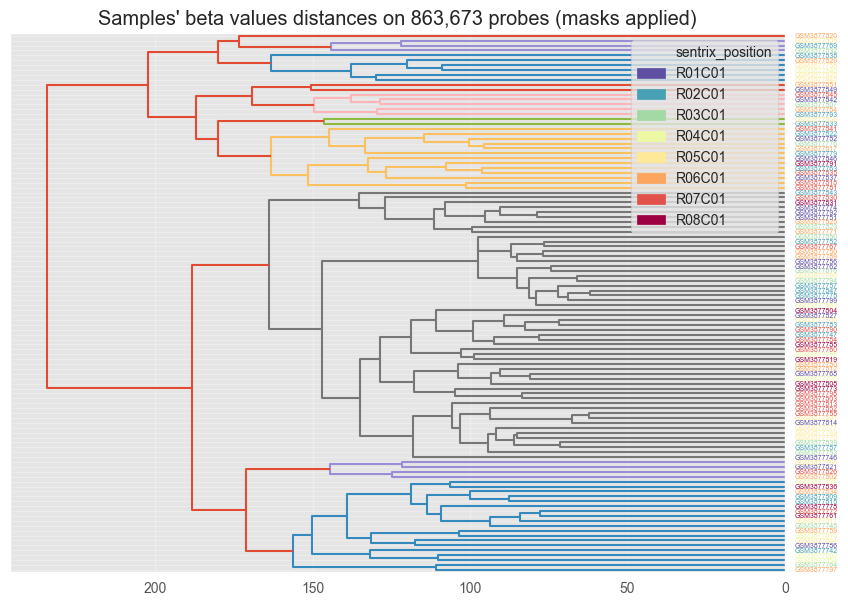

In [71]:
# Dendrogram of all samples

my_samples.calculate_betas()
betas_dendrogram(my_samples, color_column='sentrix_position')

### Appendix C - Data Loading

In [72]:
# Load just the first 10 rows to verify the data structure
hm450_sample_check = (
    pd.read_csv(
        hm450_betas_path,
        header=0,
        nrows=10,
    )
)
print("First 10 rows in the HM450 file:")
hm450_sample_check

First 10 rows in the HM450 file:


,cg00050873,cg00212031,cg00213748,cg00214611,cg00455876,cg01707559,cg02004872,cg02011394,cg02050847,cg02233190,...,rs4742386,rs2857639,rs1495031,rs1510480,rs2468330,rs7746156,rs1945975,rs966367,rs877309,rs4331560
6026818126_R01C01,0.009330,0.008243,0.004481,0.007553,0.004471,0.217557,0.000356,0.421695,0.006337,0.036584,...,0.458060,0.515290,0.465874,0.027637,0.033455,0.023195,0.494100,0.025390,0.013985,0.018543
6026818126_R04C01,0.483423,0.006942,0.326877,0.013388,0.002171,0.204184,0.010453,0.003168,0.472581,0.001687,...,0.523918,0.548342,0.030543,0.426217,0.969368,0.467315,0.508202,0.495374,0.017112,0.419504
6026818136_R01C02,0.701815,0.000040,0.587043,0.003981,0.753882,0.075759,0.006859,0.880136,0.361918,0.012925,...,0.046951,0.659621,0.536803,0.413268,0.036919,0.032173,0.544994,0.501589,0.949576,0.435305
6164655140_R01C01,0.453227,0.033324,0.010995,0.198685,0.001171,0.222685,0.000757,0.957932,0.189382,0.000667,...,0.965914,0.942339,0.464304,0.033851,0.562314,0.517308,0.909249,0.887234,0.012645,0.461247
6164655140_R03C01,0.624980,0.000019,0.107690,0.000047,0.777034,0.041512,0.000031,0.924246,0.997453,0.006533,...,0.946673,0.140969,0.024771,0.377175,0.485798,0.963912,0.644601,0.118472,0.506912,0.954910
6222421011_R01C02,0.669955,0.000019,0.792070,0.009679,0.826298,0.016755,0.004965,0.987874,0.993493,0.002527,...,0.971094,0.584789,0.494271,0.477039,0.540668,0.971203,0.574794,0.354022,0.491271,0.026892
6222421011_R02C02,0.594435,0.000954,0.993771,0.000057,0.850761,0.013623,0.007733,0.994067,0.998117,0.006300,...,0.515960,0.637431,0.016300,0.472833,0.993701,0.656832,0.526287,0.115951,0.493130,0.022630
6222421011_R03C02,0.296879,0.000025,0.991380,0.000044,0.853320,0.027895,0.000047,0.991089,0.991480,0.005726,...,0.546208,0.951103,0.024278,0.026193,0.034884,0.959062,0.032798,0.053768,0.016898,0.443289
6222421011_R04C02,0.602446,0.000554,0.987624,0.000042,0.668386,0.013687,0.000042,0.967721,0.984915,0.022208,...,0.588928,0.042460,0.480867,0.968677,0.581228,0.610535,0.030713,0.427378,0.507263,0.931497
6222421011_R06C01,0.650677,0.006941,0.993609,0.000049,0.904546,0.010734,0.011611,0.968661,0.134062,0.014296,...,0.600435,0.979800,0.491197,0.029720,0.537077,0.606132,0.610444,0.080873,0.018085,0.046815


In [73]:
# Read the HM450 betas in chunks to avoid memory issues and save to parquet for better performance

chunk_size = 100

# fix the R-style CSV (missing first cell)
with open(hm450_betas_path) as f:
    first_line = f.readline().strip().split(",")
    if first_line[0] == "":
        first_line[0] = "sample_id"  # safe placeholder for index column
    column_names = first_line

# Read in chunks
with pd.read_csv(
    hm450_betas_path,
    header=0,
    index_col=0,           # sample IDs become row index
    names=column_names,
    chunksize=chunk_size,
    engine="c",
    low_memory=False,
) as reader:

    for i, chunk in enumerate(reader):
        chunk = chunk.astype(np.float32)

        t = chunk.T
        t.index.name = "probe_id"
        t.columns.name = "sample_id"

        table = pa.Table.from_pandas(t, preserve_index=True)

        chunk_file = os.path.join(hm450_betas_pq_dir, f"hm450_chunk_{i}.parquet")
        pq.write_table(table, chunk_file, compression="snappy")

        print(f"Processed chunk {i}, shape after transpose: {t.shape}")

        # free memory
        del chunk, t, table
        gc.collect()

print("All chunks processed successfully!")

Processed chunk 0, shape after transpose: (453152, 100)
Processed chunk 1, shape after transpose: (453152, 100)
Processed chunk 2, shape after transpose: (453152, 100)
Processed chunk 3, shape after transpose: (453152, 100)
Processed chunk 4, shape after transpose: (453152, 100)
Processed chunk 5, shape after transpose: (453152, 100)
Processed chunk 6, shape after transpose: (453152, 100)
Processed chunk 7, shape after transpose: (453152, 100)
Processed chunk 8, shape after transpose: (453152, 100)
Processed chunk 9, shape after transpose: (453152, 100)
Processed chunk 10, shape after transpose: (453152, 100)
Processed chunk 11, shape after transpose: (453152, 100)
Processed chunk 12, shape after transpose: (453152, 100)
Processed chunk 13, shape after transpose: (453152, 100)
Processed chunk 14, shape after transpose: (453152, 100)
Processed chunk 15, shape after transpose: (453152, 1)
All chunks processed successfully!


### Appendix D - Data Preparation

In [74]:
# Split into train/test to avoid data leakage - save this for ICW2

'''X = hm450_prepped.drop(columns=['subtype'])
y = hm450_prepped['subtype']

X_train, X_test_hm450, y_train, y_test_hm450 = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

x_test_epic = epic_prepped.drop(columns=['subtype'])
y_test_epic = epic_prepped['subtype']'''

"X = hm450_prepped.drop(columns=['subtype'])\ny = hm450_prepped['subtype']\n\nX_train, X_test_hm450, y_train, y_test_hm450 = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)\n\nx_test_epic = epic_prepped.drop(columns=['subtype'])\ny_test_epic = epic_prepped['subtype']"

In [75]:
# Identifying probes with a correlation coefficient greater than 0.4 with the subtype labels - can only apply to training data in the full supervised pipeline for ICW2 to avoid data leakage

'''correlations = X_top_probes.apply(lambda col: np.corrcoef(col, y)[0, 1])

selected_probes = correlations[correlations > 0.4].index

X = X[selected_probes]
X'''

'correlations = X_top_probes.apply(lambda col: np.corrcoef(col, y)[0, 1])\n\nselected_probes = correlations[correlations > 0.4].index\n\nX = X[selected_probes]\nX'

## AI Declarations

Gemini was used in the original scoping of this research project: conducting a literature review on DNA methylation preprocessing, working with the GEO and handling large bioinformatics datasets. Cursor's autocomplete was used throughout the notebook to fill in boilerplate code.